# Problem set - Applied Statistics
## Sagar Clemensen (fck916)
### 3rd of January 2025

In [51]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from sympy import * 
import pandas as pd

In [52]:
from IPython.core.display import Latex

def lprint(*args,**kwargs):
    """Pretty print arguments as LaTeX using IPython display system 
    
    Parameters
    ----------
    args : tuple 
        What to print (in LaTeX math mode)
    kwargs : dict 
        optional keywords to pass to `display` 
    """
    display(Latex('$$'+' '.join(args)+'$$'),**kwargs)

In [53]:
def histogram_data(data, Nbins, range):
    counts, bin_edges = np.histogram(data, bins=Nbins, range=range)
    x = 0.5 * (bin_edges[1:] + bin_edges[:-1])/2
    y = counts
    yerr = np.sqrt(counts)
    return x, y, yerr

def weighted_mean(data, errors):
    mean = np.average(data, weights=1/(errors**2))
    error = np.sqrt(1/np.sum(1/(errors**2)))
    return mean, error

In [54]:
# General settings:
r = np.random                       # Random generator
r.seed(42)                          # Fixed order of random numbers

# Problem I - Distributions and probabilities

## 1.1

In [55]:
N_points = 1000000
pushups = np.zeros(N_points)
for i in range(N_points):
    roll = r.randint(1, 7)
    if roll == 6:
        pushups[i] = np.random.binomial(120, 1/6)
        if pushups[i] == 0:
            print('No pushups on day despite rolling a 6!')
true = np.argwhere(pushups != 0)
true = np.insert(true, 0, 0)
days_between = np.diff(true)-1

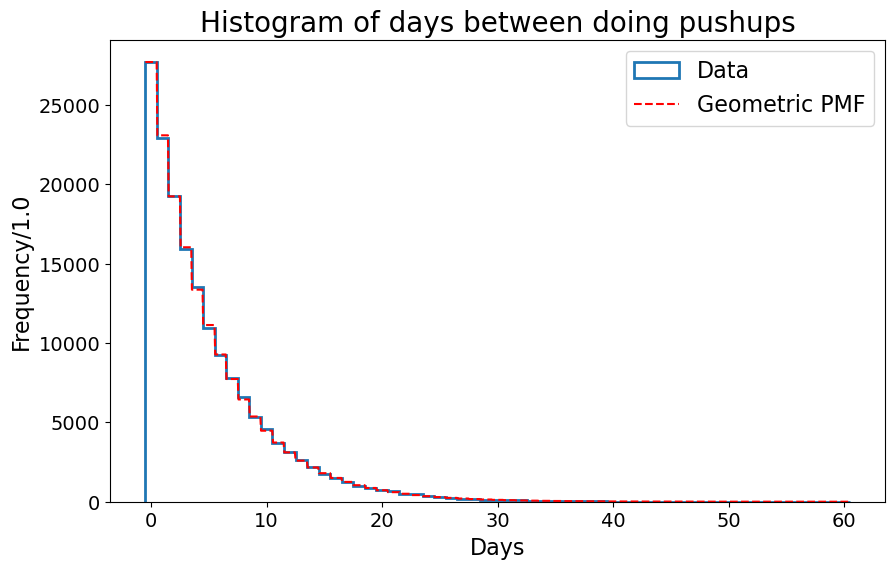

In [56]:
N_bins = 61
xmin, xmax = -0.5, 60.5
xx = np.linspace(xmin, xmax, 1000)
yy = stats.geom.pmf(np.floor(xx+1.5), 1/6)*len(days_between)
binwidth = (xmax - xmin) / N_bins
fig,ax = plt.subplots(figsize=(10,6))
ax.hist(days_between, bins=N_bins, range=(xmin, xmax), histtype='step', linewidth=2, label='Data')
ax.plot(xx, yy, 'r--', label='Geometric PMF', markersize=5)
ax.set_xlabel("Days", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth}", fontsize=16)
ax.set_title("Histogram of days between doing pushups", fontsize=20)
ax.legend(fontsize=16)
ax.tick_params(axis='both', labelsize=14);

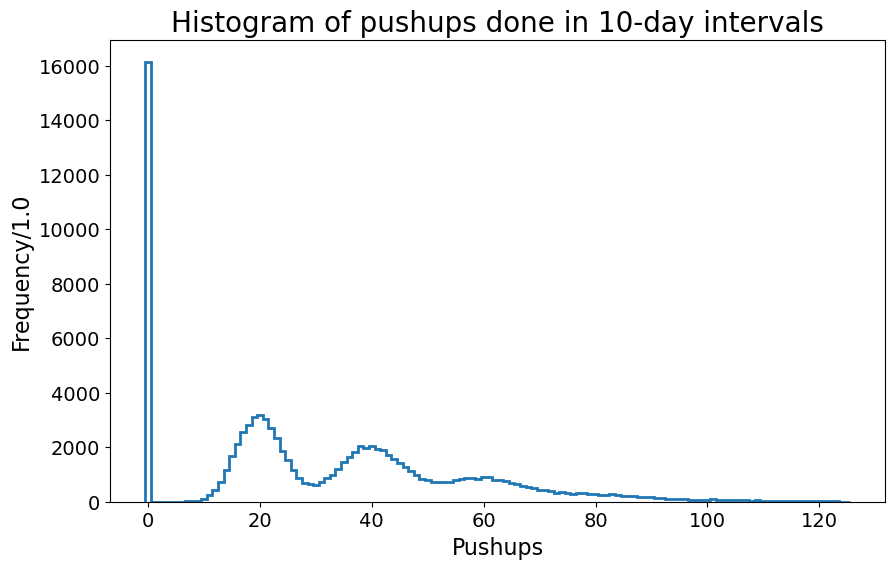

In [57]:
pushups_10days = np.sum(np.split(pushups, len(pushups)/10), axis=1)
N_bins = 126
xmin, xmax = -0.5, 125.5
binwidth = (xmax - xmin) / N_bins
fig,ax = plt.subplots(figsize=(10,6))
ax.hist(pushups_10days, bins=N_bins, range=(xmin, xmax), histtype='step', linewidth=2)
ax.set_xlabel("Pushups", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth}", fontsize=16)
ax.set_title("Histogram of pushups done in 10-day intervals", fontsize=20)
ax.tick_params(axis='both', labelsize=14);

In [58]:
mean_push10 = np.mean(pushups_10days)
std_push10 = np.std(pushups_10days)
estd_push10 = std_push10/np.sqrt(2*len(pushups_10days))
median_push10 = np.median(pushups_10days)
print(f"Standard deviation of pushups in 10 days: {std_push10:.2f} ± {estd_push10:.2f}")
print(f"Mean pushups in 10 days: {mean_push10:.2f} ± {std_push10/np.sqrt(len(pushups_10days)):.2f}")
print(f"Median pushups in 10 days: {median_push10:.2f}")

Standard deviation of pushups in 10 days: 24.11 ± 0.05
Mean pushups in 10 days: 33.24 ± 0.08
Median pushups in 10 days: 31.00


## 1.2

In [59]:
P = 6/90
print(P)

0.06666666666666667


# Problem II - Error propagation

## 2.1

In [60]:
r_earth = 149 * 1e-6
er_earth = 3 * 1e-6

r_proto = 25 * 1e-6
er_proto = 5 * 1e-6

r_comet = 309 * 1e-6
er_comet = 20 * 1e-6

# Define variables:
r_e, r_c, r_p = symbols("r_\\oplus, r_C, r_O")
dr_e, dr_c, dr_p = symbols("sigma_\\oplus, sigma_C, sigma_O")

# Define relation, and print:
frac = (r_e - r_c)/(r_p - r_c)
lprint(latex(Eq(symbols('f'),frac)))

# Calculate uncertainty and print:
dfrac = sqrt((frac.diff(r_e) * dr_e)**2 + (frac.diff(r_c) * dr_c)**2 + (frac.diff(r_p) * dr_p)**2)
lprint(latex(Eq(symbols('sigma_f'), dfrac)))

# Turn expression into numerical functions 
ffrac = lambdify((r_e,r_c,r_p),frac)
fdfrac = lambdify((r_e,dr_e,r_c,dr_c,r_p,dr_p),dfrac)


# Define values and their errors
vr_e, vr_c, vr_p = r_earth, r_comet, r_proto
vdr_e, vdr_c, vdr_p = er_earth, er_comet, er_proto

# Numerically evaluate expressions and print 
vfrac = ffrac(vr_e,vr_c,vr_p)
vdfrac = fdfrac(vr_e,vdr_e,vr_c,vdr_c,vr_p,vdr_p)
lprint(fr'f = {vfrac:.2f} \pm {vdfrac:.2f}\,')
lprint(fr'1-f = {1-vfrac:.2f} \pm {vdfrac:.2f}\,')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## 2.2

In [61]:
# Define variables:
N, t = symbols("N, deltat")
dN, dt = symbols("sigma_N, sigma_deltat")

# Define relation, and print:
rate = N/t
lprint(latex(Eq(symbols('r'),rate)))

# Calculate uncertainty and print:
drate = sqrt((rate.diff(N) * dN)**2 + (rate.diff(t) * dt)**2)
lprint(latex(Eq(symbols('sigma_r'), drate)))

# Turn expression into numerical functions 
frate = lambdify((N,t),rate)
fdrate = lambdify((N,dN,t,dt),drate)


# Define values and their errors
vN, vdN = 1971, np.sqrt(1971)
vt, vdt = 98.4, 3.7

# Numerically evaluate expressions and print 
vrate = frate(vN,vt)
vdrate = fdrate(vN,vdN,vt,vdt)
lprint(fr'r = {vrate:.1f} \pm {vdrate:.1f}\,')
lprint(fr'\%\,error = {vdrate/vrate*100:.1f}\%')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [62]:
factors = np.linspace(1, 2, 1000)
for factor in factors:
    # Define values and their errors
    vN, vdN = np.round(1971*factor,0), np.sqrt(np.round(1971*factor,0))
    vt, vdt = np.round(98.4*factor,1), 3.7
    # Numerically evaluate expressions and print 
    vrate = frate(vN,vt)
    vdrate = fdrate(vN,vdN,vt,vdt)
    if np.isclose(vdrate/vrate*100, 2.5, atol=0.001):
        print(f"Time needed to reduce relative error to below 2.5%: {vt:.2f} s")
        print(factor)
        print(vN)
        break
lprint(fr'r = {vrate:.3f} \pm {vdrate:.3f}\,')
lprint(fr'\%\,error = {vdrate/vrate*100:.4f}\%')

Time needed to reduce relative error to below 2.5%: 193.20 s
1.9629629629629628
3869.0


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [63]:
np.sqrt(3871)

np.float64(62.21736092120912)

## 2.3

In [64]:
dataframe = pd.read_csv('Data/data_PylonPositions.csv', header=0)
dataframe.values.T
idx, Ppos, Ppos_unc = dataframe.values.T
pylon1 = []
pylon2 = []
pylon3 = []
pylon4 = []
for i in range(len(Ppos)):
    if idx[i] == 0:
        pylon1.append(Ppos[i])
    elif idx[i] == 1:
        pylon2.append(Ppos[i])
    elif idx[i] == 2:
        pylon3.append(Ppos[i])
    elif idx[i] == 3:
        pylon4.append(Ppos[i])
pylon1 = np.array(pylon1)
pylon2 = np.array(pylon2)
pylon3 = np.array(pylon3)
pylon4 = np.array(pylon4)

In [65]:
def pylon_pdf_llh(x, N1, mu1, sigma1, N2, mu2, sigma2, N3, mu3, sigma3, N4, mu4, sigma4):
    gauss1 = N1 * stats.norm.pdf(x, mu1, sigma1)
    gauss2 = N2 * stats.norm.pdf(x, mu2, sigma2)
    gauss3 = N3 * stats.norm.pdf(x, mu3, sigma3)
    gauss4 = N4 * stats.norm.pdf(x, mu4, sigma4)
    return N1 + N2 + N3 + N4, gauss1 + gauss2 + gauss3 + gauss4

def pylon_pdf(x, N1, mu1, sigma1, N2, mu2, sigma2, N3, mu3, sigma3, N4, mu4, sigma4):
    gauss1 = N1 * stats.norm.pdf(x, mu1, sigma1)
    gauss2 = N2 * stats.norm.pdf(x, mu2, sigma2)
    gauss3 = N3 * stats.norm.pdf(x, mu3, sigma3)
    gauss4 = N4 * stats.norm.pdf(x, mu4, sigma4)
    return (gauss1 + gauss2 + gauss3 + gauss4) * binwidth

In [66]:
def Chauvenet_filter(data): # returns a mask of accepted data points according to Chauvenet's criterion
    mean = np.mean(data)
    std = np.std(data)
    z = np.abs(data - mean)/std
    Pt = stats.norm.sf(z)*2
    PN = Pt*len(data)
    mask = PN >= 0.5
    return mask, z

def Chauvenet(data): # Applies the mask iteratively until no more points are rejected
    accepted = data.copy()
    rejected = np.array([])
    zvals = np.array([])
    while True:
        mask, z = Chauvenet_filter(accepted)
        if np.all(mask):
            break
        inv_mask = np.logical_not(mask)
        newly_rejected = accepted[inv_mask]
        z_rej = z[inv_mask]
        rejected = np.concatenate((rejected, newly_rejected))
        zvals = np.concatenate((zvals, z_rej))
        accepted = accepted[mask]
        
    return accepted, rejected, zvals

In [67]:
pylon1_inc, pylon1_exc, pylon1_zvals = Chauvenet(pylon1)
pylon2_inc, pylon2_exc, pylon2_zvals = Chauvenet(pylon2)
pylon3_inc, pylon3_exc, pylon3_zvals = Chauvenet(pylon3)
pylon4_inc, pylon4_exc, pylon4_zvals = Chauvenet(pylon4)
Ppos1 = np.zeros(4)
ePpos1 = np.zeros(4)
for i, pylon in enumerate([pylon1_inc, pylon2_inc, pylon3_inc, pylon4_inc], start=1):
    Ppos1[i-1] = np.mean(pylon)
    std = np.std(pylon)
    ePpos1[i-1] = std / np.sqrt(len(pylon))
    print(f"Pylon {i}: Mean = {Ppos1[i-1]:.2f} ± {ePpos1[i-1]:.2f}")
    # print(f"Pylon {i}: Std Dev = {std:.1f} ")

Pylon 1: Mean = 50.69 ± 0.37
Pylon 2: Mean = 91.18 ± 0.13
Pylon 3: Mean = 131.50 ± 0.14
Pylon 4: Mean = 173.03 ± 0.12


In [68]:
for i in range(4):
    print(f"Pylon {i+1}: Rejected {len([pylon1_exc, pylon2_exc, pylon3_exc, pylon4_exc][i])} out of 30 measurements: {[pylon1_exc, pylon2_exc, pylon3_exc, pylon4_exc][i]}")
    print(f"with z-values {[pylon1_zvals, pylon2_zvals, pylon3_zvals, pylon4_zvals][i]}")
    print("")

Pylon 1: Rejected 4 out of 30 measurements: [75.341 39.348 38.946 57.19 ]
with z-values [4.20810811 2.93047714 3.03981505 2.81624715]

Pylon 2: Rejected 6 out of 30 measurements: [ 80.364 110.35  102.12   86.333  93.459  89.421]
with z-values [2.45213554 4.04784557 4.48099485 3.80220852 2.70429174 2.34921886]

Pylon 3: Rejected 2 out of 30 measurements: [137.712 139.577]
with z-values [2.95466817 3.91521344]

Pylon 4: Rejected 3 out of 30 measurements: [159.91  166.262 165.978]
with z-values [4.20372722 3.40350232 3.55718408]



In [69]:
Ppos_chauvenet = np.concatenate((pylon1_inc, pylon2_inc, pylon3_inc, pylon4_inc))
pylons = [pylon1_inc, pylon2_inc, pylon3_inc, pylon4_inc]
ullhfit = cost.ExtendedUnbinnedNLL(Ppos_chauvenet, pylon_pdf_llh)
mfit_ullh = Minuit(ullhfit, N1 = 30, mu1=50, sigma1=5.79, N2=30, mu2=90, sigma2=4.6, N3=30, mu3=131, sigma3=1.94, N4=30, mu4=170, sigma4=2.91)
mfit_ullh.migrad();

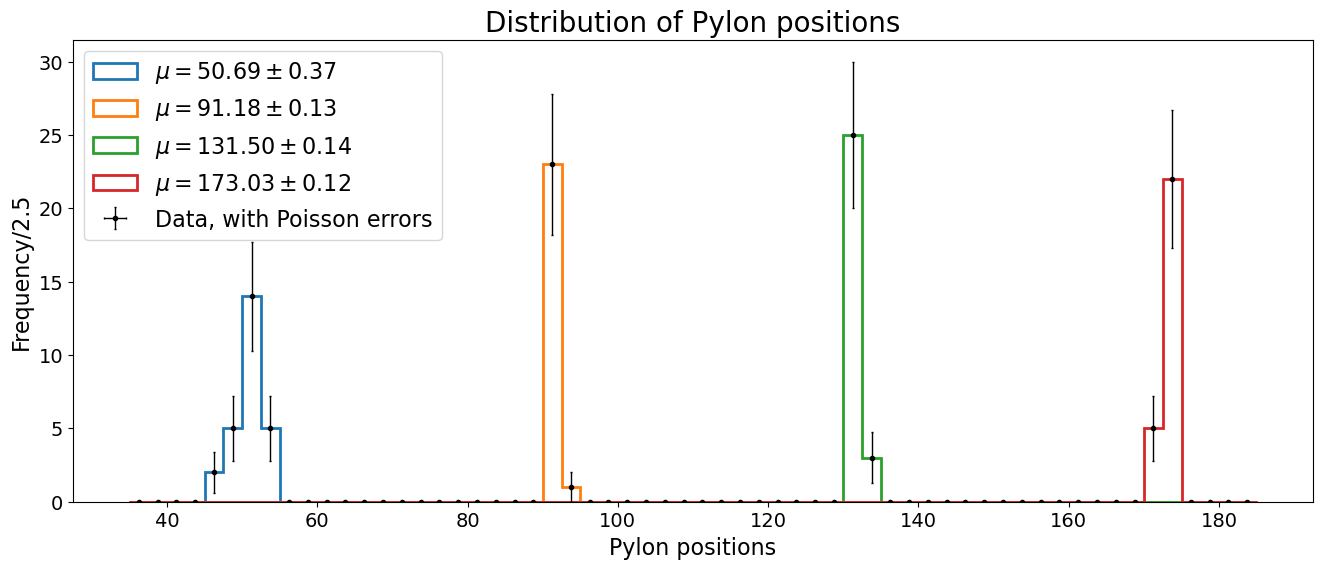

In [87]:
Nbins = 60
xmin, xmax = 35, 185
binwidth = (xmax-xmin)/Nbins
# Create just a single figure and axes, and a (classic) histogram:
fig, ax = plt.subplots(figsize=(16, 6))
for i in range(4):
    hist1 = ax.hist(pylons[i], bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2, label=rf'$\mu={Ppos1[i]:.2f} \pm {ePpos1[i]:.2f}$')
counts, bin_edges = np.histogram(Ppos_chauvenet, bins=Nbins, range=(xmin, xmax))
x = (bin_edges[1:] + bin_edges[:-1])/2
y = counts    
sy = np.sqrt(counts)
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
ax.set_xlabel("Pylon positions", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth}", fontsize=16)
ax.set_title("Distribution of Pylon positions", fontsize=20)
ax.tick_params(axis='both', labelsize=14)
ax.legend(loc='best', fontsize=16);

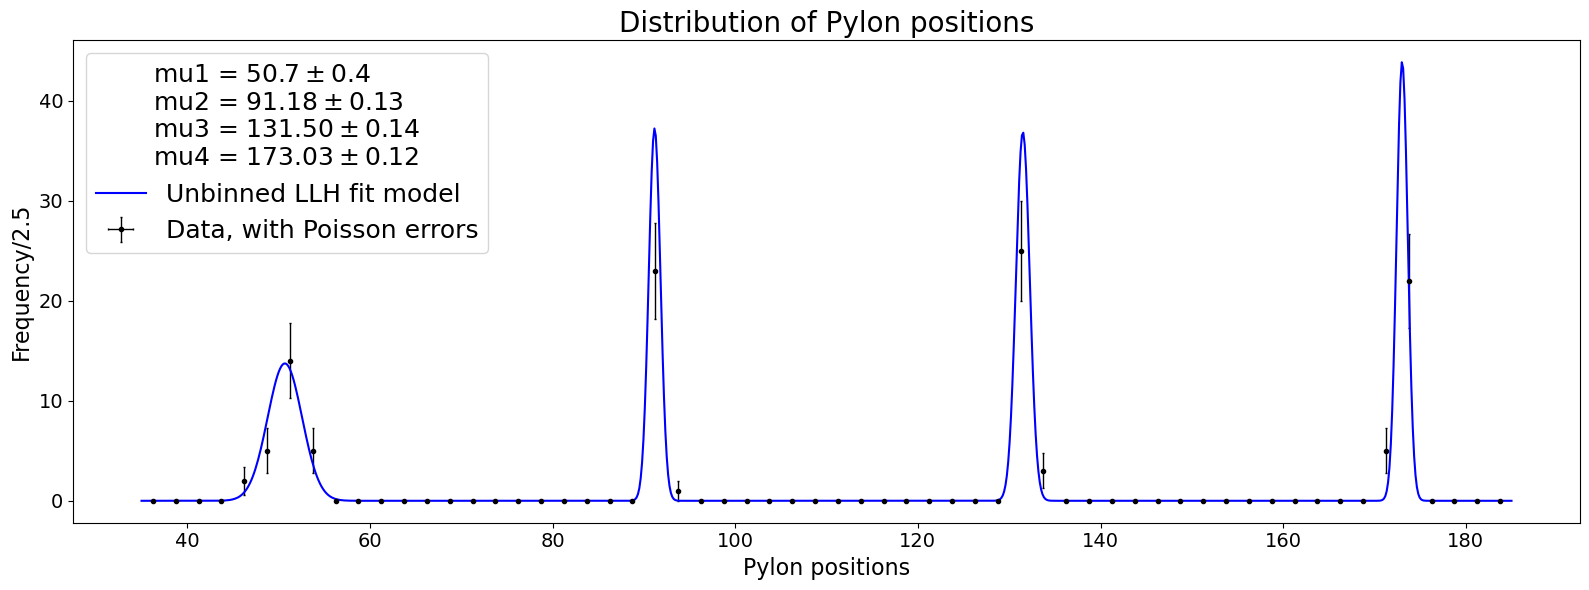

In [88]:
# Create just a single figure and axes, along with a histogram with uncertainties:
fig, ax = plt.subplots(figsize=(16, 6))  # figsize is in inches
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

ax.set_xlabel("Pylon positions", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth}", fontsize=16)
ax.set_title("Distribution of Pylon positions", fontsize=20)
ax.tick_params(axis='both', labelsize=14)
ax.legend(loc='best', fontsize=16)
xx = np.linspace(xmin, xmax, 1000)
# Adding fit info to plot:
fit_info = []
for p, v, e in zip(mfit_ullh.parameters[1::3], mfit_ullh.values[1::3], mfit_ullh.errors[1::3]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

ax.plot(xx, pylon_pdf(xx, *mfit_ullh.values[:]), '-b', label='Unbinned LLH fit model')
plt.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18, alignment = 'center');
fig.tight_layout()

In [89]:
Ppos = np.asarray(Ppos)
Ppos_unc = np.asarray(Ppos_unc)

valid_mask = Ppos_unc >= 0
invalid_mask = ~valid_mask

Ppos_valid = Ppos[valid_mask]
Ppos_unc_valid = Ppos_unc[valid_mask]

Ppos_invalid = Ppos[invalid_mask]
Ppos_unc_invalid = Ppos_unc[invalid_mask]

print(f"Valid entries: {len(Ppos_valid)}")
print(f"Invalid entries: {len(Ppos_invalid)}")

Valid entries: 40
Invalid entries: 80


In [90]:
for i in range(len(Ppos_valid)):
    print(f"The entry: Pylon position = {Ppos_valid[i]:.2f} ± {Ppos_unc_valid[i]:.2f} was considered valid")

The entry: Pylon position = 47.81 ± 1.83 was considered valid
The entry: Pylon position = 53.01 ± 1.83 was considered valid
The entry: Pylon position = 50.85 ± 1.82 was considered valid
The entry: Pylon position = 50.39 ± 1.87 was considered valid
The entry: Pylon position = 48.16 ± 1.84 was considered valid
The entry: Pylon position = 53.05 ± 1.86 was considered valid
The entry: Pylon position = 50.83 ± 1.84 was considered valid
The entry: Pylon position = 75.34 ± 1.91 was considered valid
The entry: Pylon position = 49.17 ± 1.86 was considered valid
The entry: Pylon position = 51.96 ± 1.88 was considered valid
The entry: Pylon position = 91.40 ± 1.16 was considered valid
The entry: Pylon position = 90.07 ± 0.68 was considered valid
The entry: Pylon position = 110.35 ± 0.68 was considered valid
The entry: Pylon position = 91.01 ± 0.74 was considered valid
The entry: Pylon position = 90.41 ± 0.68 was considered valid
The entry: Pylon position = 90.28 ± 0.80 was considered valid
The ent

In [91]:
z1 = abs(Ppos_valid - Ppos1[0]) / Ppos_unc_valid
z2 = abs(Ppos_valid - Ppos1[1]) / Ppos_unc_valid
z3 = abs(Ppos_valid - Ppos1[2]) / Ppos_unc_valid
z4 = abs(Ppos_valid - Ppos1[3]) / Ppos_unc_valid
Pylon1_valid = Ppos_valid[z1 < 2]
Pylon1_unc_valid = Ppos_unc_valid[z1 < 2]
Pylon2_valid = Ppos_valid[z2 < 2]
Pylon2_unc_valid = Ppos_unc_valid[z2 < 2]
Pylon3_valid = Ppos_valid[z3 < 2]
Pylon3_unc_valid = Ppos_unc_valid[z3 < 2]
Pylon4_valid = Ppos_valid[z4 < 2]
Pylon4_unc_valid = Ppos_unc_valid[z4 < 2]
for i in range(4):
    print(f"Pylon {i+1}: Using {len([Pylon1_valid, Pylon2_valid, Pylon3_valid, Pylon4_valid][i])} out of 120 measurements after validity check and pull criterion")
    print("Valid measurements: ", [Pylon1_valid, Pylon2_valid, Pylon3_valid, Pylon4_valid][i])
    print("and uncertainties: ", [Pylon1_unc_valid, Pylon2_unc_valid, Pylon3_unc_valid, Pylon4_unc_valid][i])
    print('')

Pylon 1: Using 9 out of 120 measurements after validity check and pull criterion
Valid measurements:  [47.813 53.014 50.852 50.391 48.16  53.047 50.831 49.171 51.958]
and uncertainties:  [1.83  1.831 1.821 1.874 1.838 1.856 1.841 1.863 1.881]

Pylon 2: Using 7 out of 120 measurements after validity check and pull criterion
Valid measurements:  [91.403 90.068 91.008 90.411 90.275 90.463 92.582]
and uncertainties:  [1.162 0.676 0.74  0.675 0.804 0.81  0.993]

Pylon 3: Using 8 out of 120 measurements after validity check and pull criterion
Valid measurements:  [132.792 130.587 131.47  131.74  131.612 131.737 130.139 130.86 ]
and uncertainties:  [0.818 0.846 0.673 0.929 0.771 0.671 0.727 0.741]

Pylon 4: Using 9 out of 120 measurements after validity check and pull criterion
Valid measurements:  [172.356 173.611 172.996 173.446 172.586 173.253 173.993 172.37  174.054]
and uncertainties:  [0.681 0.979 1.052 0.746 0.672 1.118 0.722 0.889 0.67 ]



In [92]:
Ppos2 = np.zeros(4)
ePpos2 = np.zeros(4)

for i, (pylon, pylon_unc) in enumerate(zip([Pylon1_valid, Pylon2_valid, Pylon3_valid, Pylon4_valid],
                                           [Pylon1_unc_valid, Pylon2_unc_valid, Pylon3_unc_valid, Pylon4_unc_valid]), start=1):
    Ppos2[i-1], ePpos2[i-1] = weighted_mean(pylon, pylon_unc)
    chi2 = np.sum(((pylon - Ppos2[i-1]) / pylon_unc) ** 2)
    ndof = len(pylon) - 1
    Prob = stats.chi2.sf(chi2, ndof)
    print(f"Pylon {i}: Weighted Mean = {Ppos2[i-1]:.1f} ± {ePpos2[i-1]:.1f}")
    print(f"Pylon {i}: Chi2/ndof = {chi2:.1f}/{ndof}, Prob = {Prob:.2f}")
    print('')

Pylon 1: Weighted Mean = 50.6 ± 0.6
Pylon 1: Chi2/ndof = 8.7/8, Prob = 0.37

Pylon 2: Weighted Mean = 90.7 ± 0.3
Pylon 2: Chi2/ndof = 5.6/6, Prob = 0.48

Pylon 3: Weighted Mean = 131.3 ± 0.3
Pylon 3: Chi2/ndof = 7.8/7, Prob = 0.35

Pylon 4: Weighted Mean = 173.2 ± 0.3
Pylon 4: Chi2/ndof = 6.4/8, Prob = 0.60



In [76]:
for i in range(len(Ppos1)):
    z = np.abs(Ppos1[i] - Ppos2[i]) / np.sqrt(ePpos1[i]**2 + ePpos2[i]**2)
    p = 2*stats.norm.sf(z)
    print(f"Pylon {i+1}: z-value between weighted average and average = {z:.2f}, p-value = {p:.2f}")

Pylon 1: z-value between weighted average and average = 0.17, p-value = 0.87
Pylon 2: z-value between weighted average and average = 1.46, p-value = 0.14
Pylon 3: z-value between weighted average and average = 0.51, p-value = 0.61
Pylon 4: z-value between weighted average and average = 0.58, p-value = 0.56


In [93]:
Ppos_final = np.zeros(4)
ePpos_final = np.zeros(4)
for i in range(len(Ppos1)):
    Ppos_final[i], ePpos_final[i] = weighted_mean(np.array([Ppos1[i], Ppos2[i]]), np.array([ePpos1[i], ePpos2[i]]))
    print(f"Pylon {i+1}: Final Weighted Mean = {Ppos_final[i]:.1f} ± {ePpos_final[i]:.1f}")

Pylon 1: Final Weighted Mean = 50.7 ± 0.3
Pylon 2: Final Weighted Mean = 91.1 ± 0.1
Pylon 3: Final Weighted Mean = 131.5 ± 0.1
Pylon 4: Final Weighted Mean = 173.1 ± 0.1


In [108]:
def lin_func(x, a, b):
    return a * x + b

In [111]:
cfit_diff = cost.LeastSquares(np.arange(1,5), Ppos_final, ePpos_final, lin_func)
mfit_diff = Minuit(cfit_diff, a=1.0, b=0)
mfit_diff.migrad();

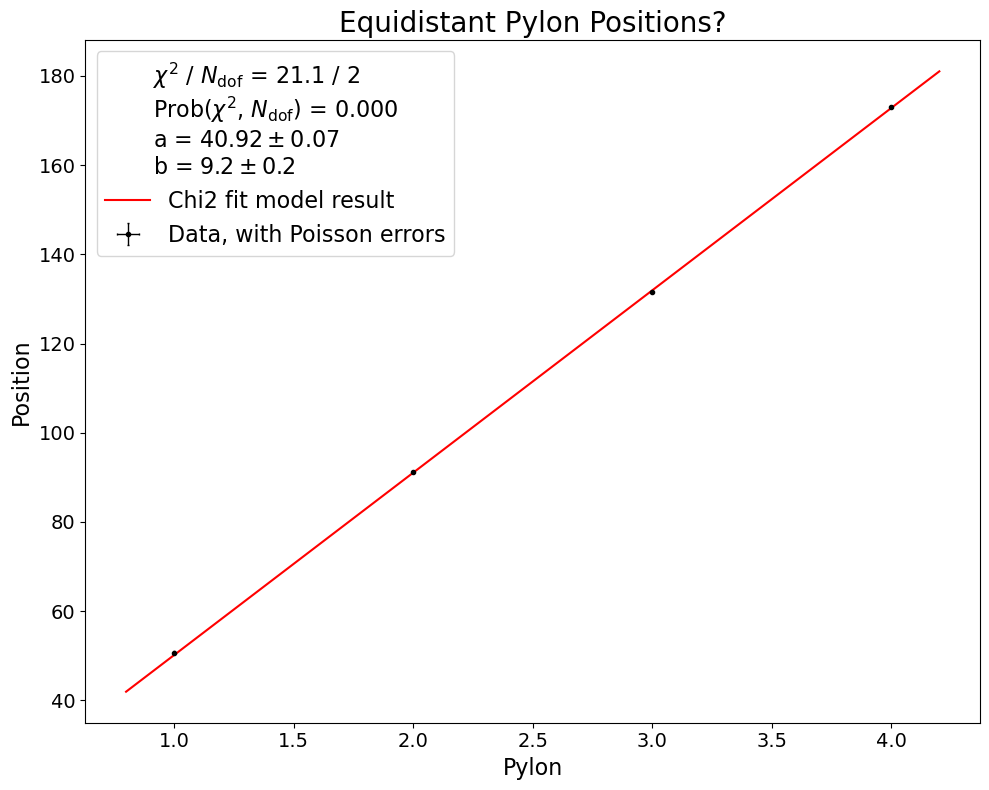

In [112]:
# Create just a single figure and axes, along with a histogram with uncertainties:
fig_chi2, ax_chi2 = plt.subplots(figsize=(10, 8))  # figsize is in inches
ax_chi2.errorbar(np.arange(1,5), Ppos_final, yerr=ePpos_final, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

ax_chi2.set_xlabel("Pylon", fontsize=16)
ax_chi2.set_ylabel('Position', fontsize=16)
ax_chi2.set_title("Equidistant Pylon Positions?", fontsize=20)
ax_chi2.tick_params(axis='both', labelsize=14)

# Adding fit function to plot:
x_axis1 = np.linspace(0.8, 4.2, 1000)
ax_chi2.plot(x_axis1, lin_func(x_axis1, *mfit_diff.values[:]), '-r', label= r"Chi2 fit model result") 
# Adding fit results to plot:
chi2 = mfit_diff.fval                     # ChiSquare value
Ndof = len(np.arange(1,5)) - mfit_diff.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit_diff.parameters, mfit_diff.values[:], mfit_diff.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');
fig_chi2.tight_layout()

# Problem III - Simulation / Monte Carlo

## 3.1

In [80]:
r.seed(42)                          # Fixed order of random numbers
N_points = 100000    # Number of random points to be generated

xmin_A, xmax_A = -6, 6
ymin_A, ymax_A = -6, 6

pos_A = np.zeros((N_points, 2))
# overlaps_A = []
overlaps_A = np.zeros((N_points, 2))
N_overlap_A = 0
for i in range(N_points):
    while True:
        x = r.uniform(xmin_A, xmax_A)  
        y = r.uniform(ymin_A, ymax_A)        
        if (x**2 + y**2 < 6**2) :   # If the (x,y)-point fulfills the accept condition...
            break      
    pos_A[i] = x,y
    if ((x-3)**2 + (y-7)**2 < 4**2) :   # If the (x,y)-point fulfills the accept condition...
        N_overlap_A += 1
        overlaps_A[i] = x,y
        # overlaps_A.append((x,y))
# overlaps_A = np.array(overlaps_A)
frac_A = N_overlap_A/N_points
xmin_B, xmax_B =  3-4, 3+4
ymin_B, ymax_B =  7-4, 7+4

pos_B = np.zeros((N_points, 2))
# overlaps_B = []
overlaps_B = np.zeros((N_points, 2))
N_overlap_B = 0
for i in range(N_points):
    while True:
        x = r.uniform(xmin_B, xmax_B)  
        y = r.uniform(ymin_B, ymax_B)        
        if ((x-3)**2 + (y-7)**2 < 4**2) :   # If the (x,y)-point fulfills the accept condition...
            break      
    pos_B[i] = x,y
    if (x**2 + y**2 < 6**2) :   # If the (x,y)-point fulfills the accept condition...
        N_overlap_B += 1
        overlaps_B[i] = x,y
#         overlaps_B.append((x,y))
# overlaps_B = np.array(overlaps_B)
frac_B = N_overlap_B/N_points

In [81]:
pos_A_filtered = pos_A[~np.isin(pos_A, overlaps_A).all(axis=1)]
pos_B_filtered = pos_B[~np.isin(pos_B, overlaps_B).all(axis=1)]
overlaps_A = overlaps_A[np.any(overlaps_A != 0, axis=1)]
overlaps_B = overlaps_B[np.any(overlaps_B != 0, axis=1)]

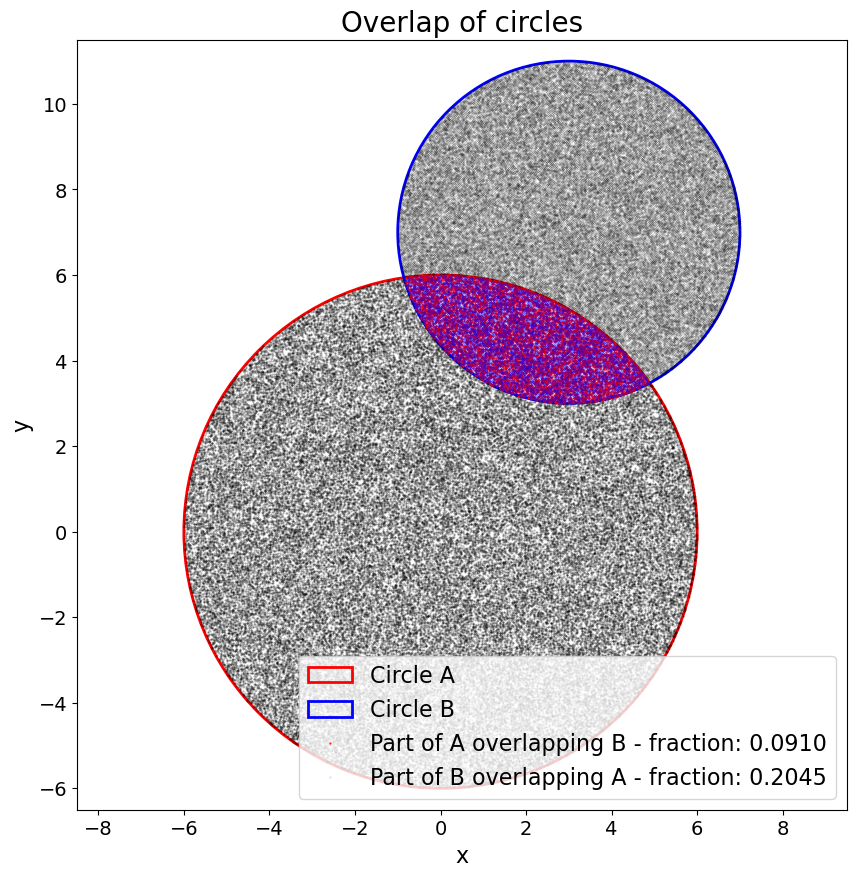

In [82]:
fig, ax = plt.subplots(figsize=(10, 10))
import matplotlib.patches as mpatches
c1 = mpatches.Circle((0, 0), 6, edgecolor='r', fill=False, linewidth=2, label='Circle A')
c2 = mpatches.Circle((3, 7), 4, edgecolor='b', fill=False, linewidth=2, label='Circle B')
ax.add_patch(c1)
ax.add_patch(c2)
ax.plot(pos_A_filtered[:,0], pos_A_filtered[:,1], '.k', markersize=1, alpha=0.3)
ax.plot(pos_B_filtered[:,0], pos_B_filtered[:,1], '.k', markersize=0.44, alpha =0.3)
ax.plot(overlaps_A[:,0], overlaps_A[:,1], '.r', markersize=1, label='Part of A overlapping B - fraction: {:.4f}'.format(frac_A))
ax.plot(overlaps_B[:,0], overlaps_B[:,1], '.b', markersize=0.44,  label='Part of B overlapping A - fraction: {:.4f}'.format(frac_B), alpha=0.4)
ax.set_xlabel('x', fontsize=16)
ax.set_ylabel('y', fontsize=16)
ax.set_title('Overlap of circles', fontsize=20)
ax.tick_params(axis='both', labelsize=14)
ax.set(xlim=(-6.5-2, 7.5+2), ylim=(-6.5, 11.5), aspect='equal');
ax.legend(loc='best', fontsize=16);

In [83]:
xmin_A, xmax_A = -6, 6
ymin_A, ymax_A = -6, 6
zmin_A, zmax_A = -6, 6
wmin_A, wmax_A = -6, 6

pos = np.zeros((N_points, 4))
overlaps = []
Ntry = 0
N_overlap = 0
for i in range(N_points):
    while True:
        Ntry += 1
        x = r.uniform(xmin_A, xmax_A)  
        y = r.uniform(ymin_A, ymax_A)  
        z = r.uniform(zmin_A, zmax_A)
        w = r.uniform(wmin_A, wmax_A)      
        if (x**2 + y**2 + z**2 + w**2 < 6**2) :   # If the (x,y)-point fulfills the accept condition...
            break      
    pos[i] = x,y,z,w
    if ((x-3)**2 + (y-7)**2 + (z+1)**2 + (w-2)**2 < 4**2) :   # If the (x,y)-point fulfills the accept condition...
        N_overlap += 1
        overlaps.append((x,y,z,w))
overlaps = np.array(overlaps)

frac_A = N_overlap/N_points


xmin_B, xmax_B =  3-4, 3+4
ymin_B, ymax_B =  7-4, 7+4
zmin_B, zmax_B =  -1-4, -1+4
wmin_B, wmax_B =  2-4, 2+4

pos = np.zeros((N_points, 4))
overlaps = []
Ntry = 0
N_overlap = 0
for i in range(N_points):
    while True:
        Ntry += 1
        x = r.uniform(xmin_B, xmax_B)  
        y = r.uniform(ymin_B, ymax_B)
        z = r.uniform(zmin_B, zmax_B)
        w = r.uniform(wmin_B, wmax_B)        
        if ((x-3)**2 + (y-7)**2 + (z+1)**2 + (w-2)**2 < 4**2) :   # If the (x,y)-point fulfills the accept condition...
            break      
    pos[i] = x,y,z,w
    if (x**2 + y**2 + z**2 + w**2 < 6**2) :   # If the (x,y)-point fulfills the accept condition...
        N_overlap += 1
        overlaps.append((x,y,z,w))
overlaps = np.array(overlaps)

frac_B = N_overlap/N_points
print(f"Fraction of A overlapping B: {frac_A:.5f}")
print(f"Fraction of B overlapping A: {frac_B:.5f}")

KeyboardInterrupt: 

## 3.2

In [ ]:
N_points = 50000
pos = np.zeros((N_points, 3))
for i in range(N_points):
        x = r.uniform(-1, 1)  
        y = r.uniform(-1, 1)
        z = r.uniform(-1, 1)
        pos[i] = x,y,z
radius_cube = np.sqrt(pos[:,0]**2 + pos[:,1]**2 + pos[:,2]**2)

0.01


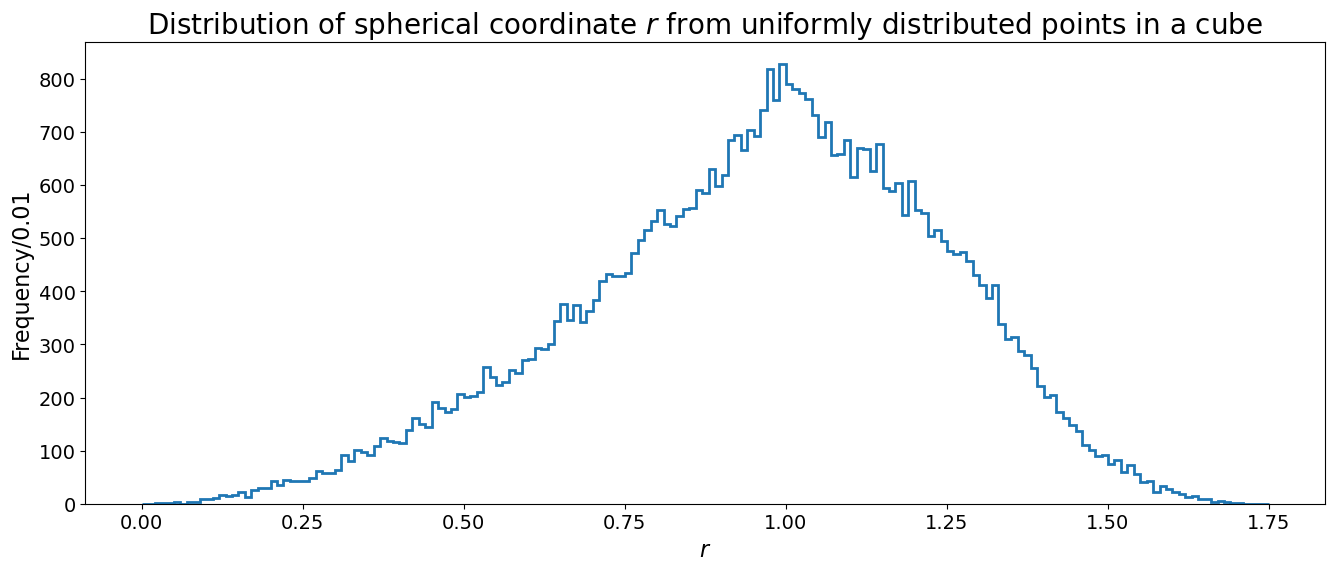

In [ ]:
Nbins = 175
xmin, xmax = 0, 1.75
binwidth = (xmax-xmin)/Nbins
print(binwidth)

# Create just a single figure and axes, and a (classic) histogram:
fig, ax = plt.subplots(figsize=(16, 6))
hist = ax.hist(radius_cube, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2)
ax.set_xlabel("$r$", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth}", fontsize=16)
ax.set_title("Distribution of spherical coordinate $r$ from uniformly distributed points in a cube", fontsize=20)
ax.tick_params(axis='both', labelsize=14);

In [ ]:
pos_filtered = pos[(pos[:,2] > 0) & (np.sqrt(pos[:,0]**2 + pos[:,1]**2 + pos[:,2]**2) < 1)]
theta = np.atan2(np.sqrt(pos_filtered[:,0]**2 + pos_filtered[:,1]**2), pos_filtered[:,2])
phi = np.arctan2(pos_filtered[:,1], pos_filtered[:,0])
theta_degrees = theta * 180 / np.pi
phi_degrees = phi * 180 / np.pi

13321


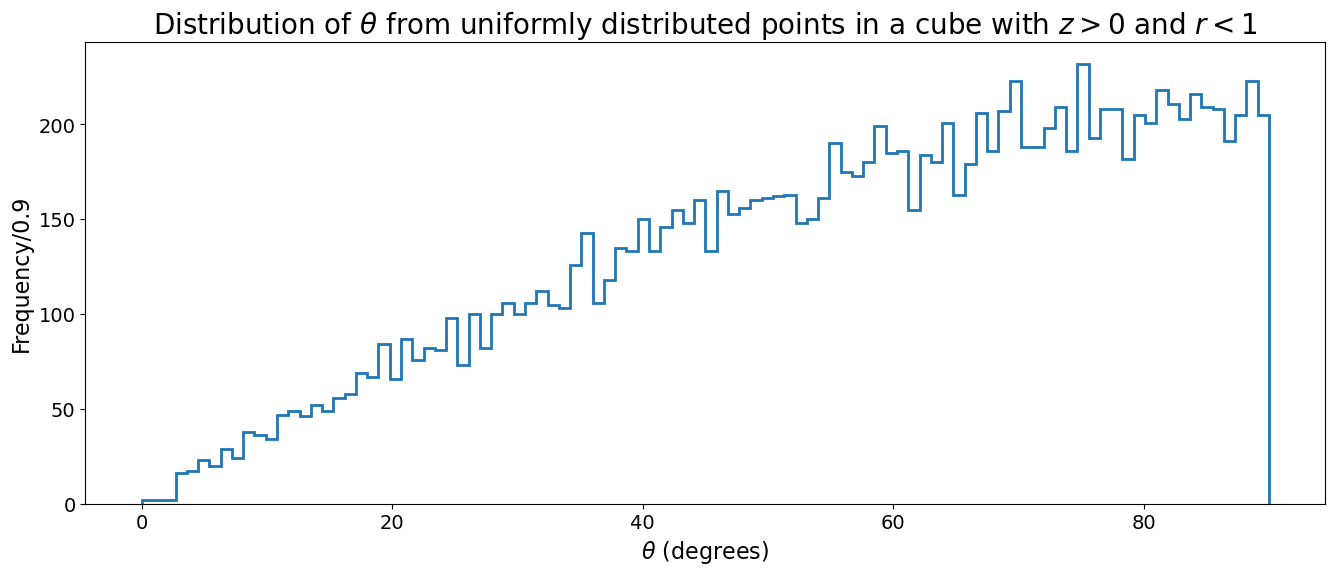

In [ ]:
Nbins = 100
xmin, xmax = 0, 90
binwidth = (xmax-xmin)/Nbins
print(len(theta_degrees))

# Create just a single figure and axes, and a (classic) histogram:
fig, ax = plt.subplots(figsize=(16, 6))
hist = ax.hist(theta_degrees, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2)
ax.set_xlabel("$\\theta$ (degrees)", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth}", fontsize=16)
ax.set_title("Distribution of $\\theta$ from uniformly distributed points in a cube with $z > 0$ and $r < 1$", fontsize=20)
ax.tick_params(axis='both', labelsize=14);

13321


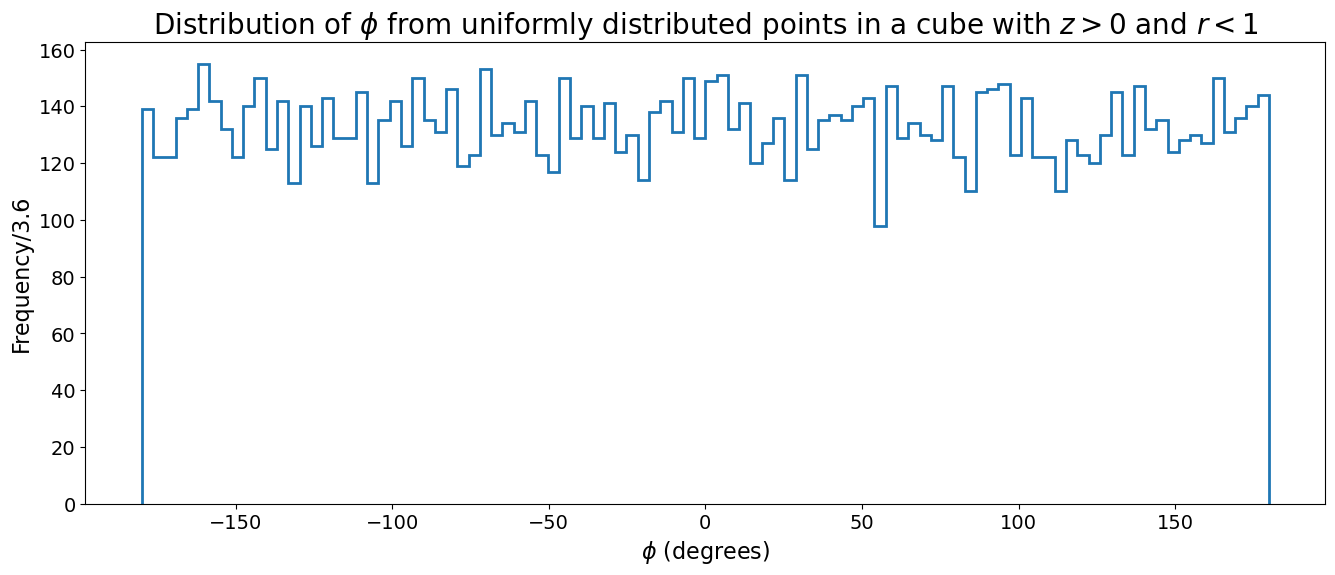

In [ ]:
Nbins = 100
xmin, xmax = -180, 180
binwidth = (xmax-xmin)/Nbins
print(len(phi))

# Create just a single figure and axes, and a (classic) histogram:
fig, ax = plt.subplots(figsize=(16, 6))
hist = ax.hist(phi_degrees, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2)
ax.set_xlabel("$\\phi$ (degrees)", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth}", fontsize=16)
ax.set_title("Distribution of $\\phi$ from uniformly distributed points in a cube with $z > 0$ and $r < 1$", fontsize=20)
ax.tick_params(axis='both', labelsize=14);

In [ ]:
def f1(x, x0):
    return 1/(2*x0) * (x/x0)**2 * np.exp(-x/x0) 

In [ ]:
len(theta)

13011

In [ ]:
N_points = len(theta)    # Number of random points to be generated
N_try = 0
xmin, xmax = 0, 1300
xx = np.linspace(xmin, xmax, 10000)
yy = f1(xx, 100)

ymin = np.min(yy)      # Minimum value the function will take!
ymax = np.max(yy)      # Maximum value the function will take!
print(ymax)
velocities = np.zeros(N_points)

for i in range(N_points):
    while True:
        # Count the number of tries, to get efficiency/integral
        N_try += 1                    
        # Range that f(x) is defined/wanted in:
        x_test = r.uniform(xmin, xmax)  
        
        # Upper bound for function values:
        y_test = r.uniform(ymin, ymax)
        
        if (y_test < f1(x_test, 100)) :   # If the (x,y)-point fulfills the accept condition...
            break
            
    velocities[i] = x_test

# Efficiency
eff = N_points / N_try                        

# Error on efficiency (binomial!)
eff_error = np.sqrt(eff * (1-eff) / N_try) 

# Integral
integral =  eff * (xmax-xmin) * (ymax-ymin)

# Error on integral
eintegral = eff_error * (xmax-xmin) * (ymax-ymin)  


print(f"The efficiency of the Accept/Reject method used here is: \t {eff:.2%} +/- {eff_error:.2%}")
# We normalized the function ahead of time, so we should hope to get a result consistent with unity!

0.0027067055564279304
The efficiency of the Accept/Reject method used here is: 	 28.44% +/- 0.21%


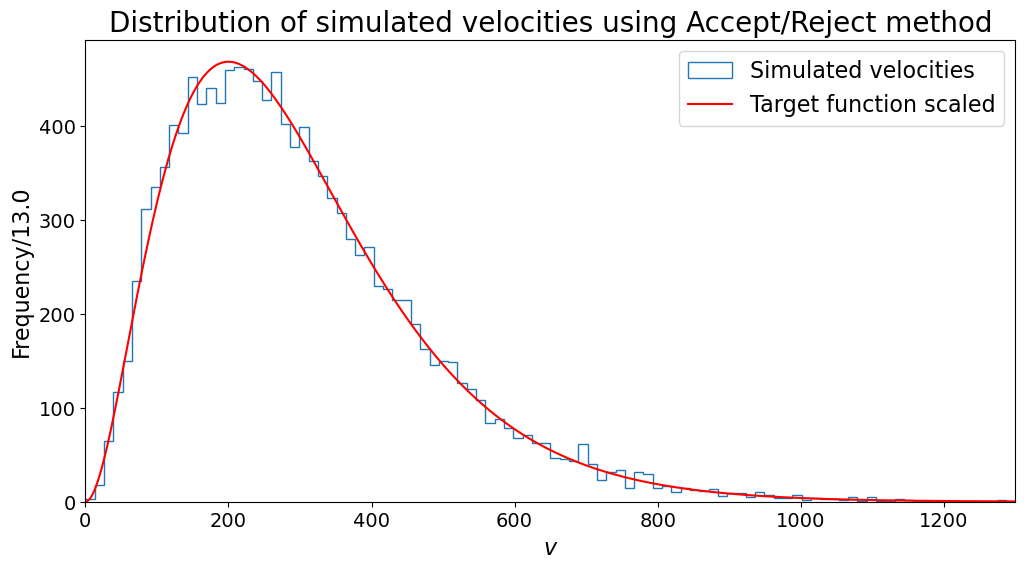

In [ ]:
N_bins = 100
binwidth = (xmax - xmin)/N_bins

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(velocities, bins=N_bins, range=(xmin, xmax), histtype='step', label='Simulated velocities')
ax.set_xlabel("$v$", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth}", fontsize=16)
ax.set_title("Distribution of simulated velocities using Accept/Reject method", fontsize=20)
ax.set_xlim(xmin, xmax)
ax.plot(xx, f1(xx, 100)*N_points*binwidth/integral, 'r-', label='Target function scaled')
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=16);

172945.62255819084
1750.0


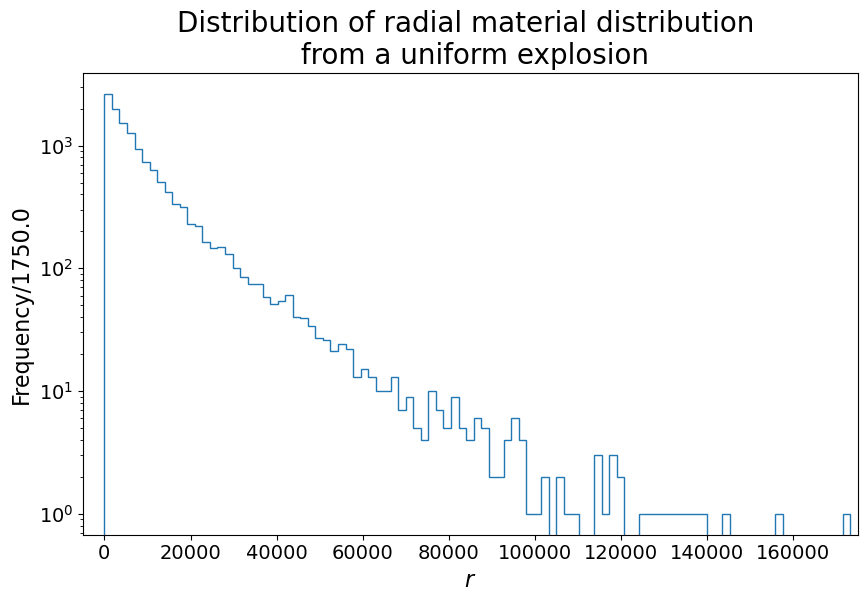

In [ ]:
radius = np.sin(theta) * velocities**2/9.
print(np.max(radius))
xmin_r, xmax_r = 0, 175000
# xmax_r = 60000
N_bins_r = 100
binwidth_r = (xmax_r - xmin_r)/N_bins_r
print(binwidth_r)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(radius, bins=N_bins_r, range=(xmin_r, xmax_r), histtype='step')
ax.set_xlabel("$r$", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth_r}", fontsize=16)
ax.set_title("Distribution of radial material distribution \n from a uniform explosion", fontsize=20)
ax.set_xlim(xmin_r-5000, xmax_r)
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=14);

# Problem IV - Statistical tests

## 4.1

In [ ]:
def pearsons_chi2(data, model) :
    return np.sum( (data - model)**2 / model )

In [ ]:
def die_rolling_test(N_rolls, blinded):
    r = np.random             # Random generator
    r.seed(137)                # Set a random seed (but a fixed one)

    i = 0
    die_rolls = []
    while i<N_rolls:
        for j in range(25):
            roll = r.randint(1, 7)
            die_rolls.append(roll)
        i += 1

    i = 0
    die_rolls_fake = []
    side = r.randint(1, 7)
    if not blinded:
        print(f"Fake side chosen: {side}")
    while i<N_rolls:
        for j in range(24):
            roll = r.randint(1, 7)
            die_rolls_fake.append(roll)
        die_rolls_fake.append(side)
        i += 1

    decider = r.uniform(0,1)

    if blinded:
        if decider < 0.5:
            die_rolls_A = die_rolls
            die_rolls_B = die_rolls_fake
        else:
            die_rolls_A = die_rolls_fake
            die_rolls_B = die_rolls
    # Create just a single figure and axes, and a (classic) histogram:
    fig, ax = plt.subplots(figsize=(16, 6))
    if blinded:
        ax.hist(die_rolls_A, bins=6, range=(0.5, 6.5), histtype='step', linewidth=2, label='Dataset A')
        ax.hist(die_rolls_B, bins=6, range=(0.5, 6.5), histtype='step', linewidth=2, label='Dataset B')
        counts, bin_edges = np.histogram(die_rolls_A, bins=6, range=(0.5, 6.5))
        x_a = (bin_edges[1:] + bin_edges[:-1])/2
        y_a = counts
        counts, bin_edges = np.histogram(die_rolls_B, bins=6, range=(0.5, 6.5))
        x_b = (bin_edges[1:] + bin_edges[:-1])/2
        y_b = counts

        true_counts = np.full_like(x_a, len(die_rolls_A)/6)
        ax.plot(np.linspace(0.5, 6.5, 10), len(die_rolls_A)/6 * np.ones(10), 'r--', label='Expected uniform distribution')

        chi2_a = pearsons_chi2(y_a, true_counts)
        prob_a = stats.chi2.sf(chi2_a, df=len(x_a)-1)
        chi2_b = pearsons_chi2(y_b, true_counts)
        prob_b = stats.chi2.sf(chi2_b, df=len(x_b)-1)
        fit_info = [f"Pearsons $\\chi^2_A$ / $N_\\mathrm{{dof}}$ = {chi2_a:.1f} / {len(x_a)-1}", f"Prob($\\chi^2_A$, $N_\\mathrm{{dof}}$) = {prob_a:.3f}",]
        fit_info += [f"Pearsons $\\chi^2_B$ / $N_\\mathrm{{dof}}$ = {chi2_b:.1f} / {len(x_b)-1}", f"Prob($\\chi^2_B$, $N_\\mathrm{{dof}}$) = {prob_b:.3f}",]
        # Put fit info as a text box inside the plot
        ax.text(
            0.9, 0.66,
            "\n".join(fit_info),
            transform=ax.transAxes,
            fontsize=16,
            va='top', ha='right',
            bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.8)
        )
    else:
        if decider < 0.5:
            print("Dataset B had the fake die")
            ax.hist(die_rolls, bins=6, range=(0.5, 6.5), histtype='step', linewidth=2, label='Die rolls', color='C0')
            ax.hist(die_rolls_fake, bins=6, range=(0.5, 6.5), histtype='step', linewidth=2, label=f'Die rolls with one fake die (side {side})', color='C1')
        else:
            print("Dataset A had the fake die")
            ax.hist(die_rolls, bins=6, range=(0.5, 6.5), histtype='step', linewidth=2, label='Die rolls', color='C1')
            ax.hist(die_rolls_fake, bins=6, range=(0.5, 6.5), histtype='step', linewidth=2, label=f'Die rolls with one fake die (side {side})', color='C0')
    ax.set_xlabel("Die roll", fontsize=16)
    ax.set_ylabel("Frequency", fontsize=16)
    if blinded:
        ax.set_title("Distribution of die rolls (blinded)", fontsize=20)
        ax.tick_params(axis='both', labelsize=14)
        ax.legend(loc='best', fontsize=20);
    else:
        ax.set_title("Distribution of die rolls", fontsize=20)
        ax.tick_params(axis='both', labelsize=14)
        ax.legend(loc='best', fontsize=20);

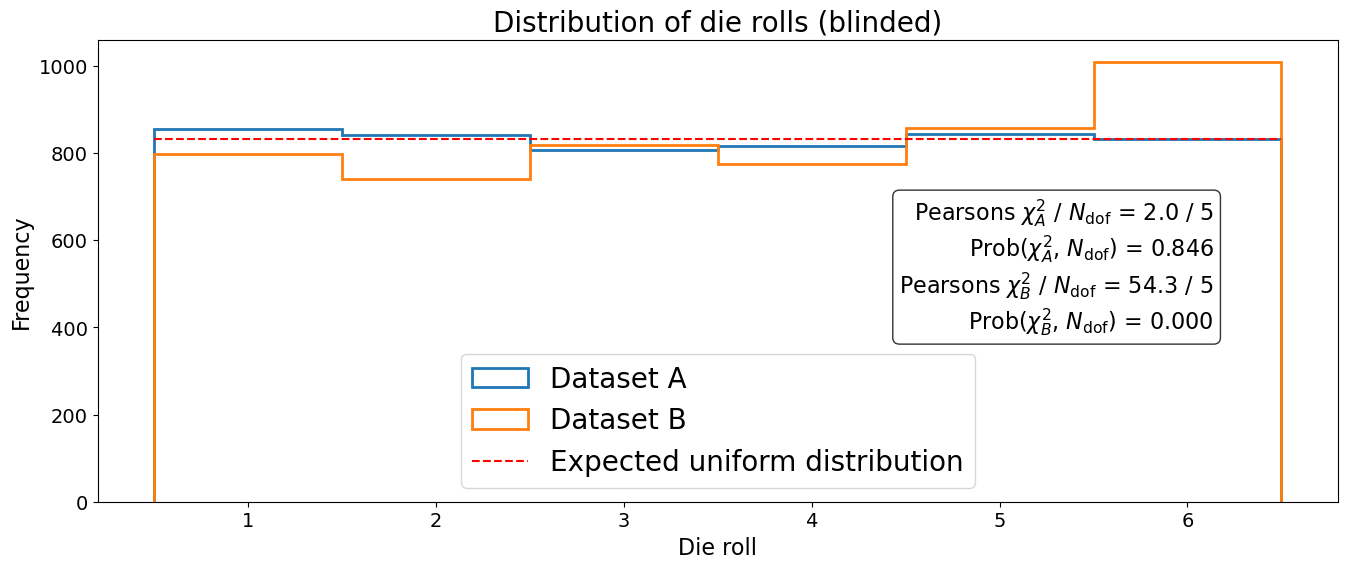

In [ ]:
die_rolling_test(200, blinded=True)

In [ ]:
seeds = np.arange(1000)
max_wrong_arg = np.zeros(len(seeds))
r = np.random

max_rolls = 200

for n in range(len(seeds)):
    r.seed(seeds[n])

    randint = r.randint
    chi2 = pearsons_chi2
    counts_real = np.zeros(6)
    counts_fake = np.zeros(6)
    side = randint(1, 7)
    correct = np.zeros(max_rolls, dtype=bool)

    for N_rolls in range(1, max_rolls + 1):
        new_real = r.randint(1, 7, size=25)
        new_fake = r.randint(1, 7, size=25)

        # force fake bias (1 per iteration)
        new_fake[0] = side

        # update cumulative counts
        counts_real += np.bincount(new_real - 1, minlength=6)
        counts_fake += np.bincount(new_fake - 1, minlength=6)

        # rolls_real = randint(1, 7, size=25 * N_rolls)
        # counts_real = np.bincount(rolls_real - 1, minlength=6)

        # rolls_fake = randint(1, 7, size=25 * N_rolls)
        # rolls_fake[:N_rolls] = side
        # counts_fake = np.bincount(rolls_fake - 1, minlength=6)

        expected = (25 * N_rolls) / 6

        chi2_real = chi2(counts_real, expected)
        chi2_fake = chi2(counts_fake, expected)
        correct[N_rolls - 1] = chi2_real < chi2_fake

    wrong = np.where(~correct)[0]
    max_wrong_arg[n] = wrong.max() + 1 if len(wrong) else 0

In [ ]:
xmin, xmax = 0, 160
N_bins = 80
binwidth = (xmax - xmin)/N_bins

limit_1 = 110
within_1 = max_wrong_arg[max_wrong_arg < limit_1]
amount_1 = len(within_1)/len(max_wrong_arg)

limit_5 = 75
within_5 = max_wrong_arg[max_wrong_arg < limit_5]
amount_5 = len(within_5)/len(max_wrong_arg)

fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(within_1, bins=N_bins, range=(xmin, xmax), histtype='bar', linewidth=2, alpha=0.5, label=f'Max die rolls < {limit_1}. Amount: {amount_1*100:.2f}%')
ax.hist(within_5, bins=N_bins, range=(xmin, xmax), histtype='bar', linewidth=2, alpha=0.5, label=f'Max die rolls < {limit_5}. Amount: {amount_5*100:.2f}%')
ax.hist(max_wrong_arg, bins=N_bins, range=(xmin, xmax), histtype='step', linewidth=2, label='All max die rolls')
ax.set_xlabel("Amount of die rolls", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth}", fontsize=16)
ax.set_title("Distribution of maximum die rolls \n where the frequency test fails to determine if there is a fake die", fontsize=20)
ax.tick_params(axis='both', labelsize=14)
ax.legend(loc='best', fontsize=16);

NameError: name 'max_wrong_arg' is not defined

In [ ]:
def tracingp_dies(seeds, max_rolls=100):
    r = np.random
    r.seed(seeds)

    side = r.randint(1, 7)

    pvals_real = np.zeros(max_rolls)
    pvals_fake = np.zeros(max_rolls)

    # cumulative counts
    counts_real = np.zeros(6)
    counts_fake = np.zeros(6)

    for N_rolls in range(1, max_rolls + 1):

        # generate ONLY new rolls
        new_real = r.randint(1, 7, size=25)
        new_fake = r.randint(1, 7, size=25)

        # force fake bias (1 per iteration)
        new_fake[0] = side

        # update cumulative counts
        counts_real += np.bincount(new_real - 1, minlength=6)
        counts_fake += np.bincount(new_fake - 1, minlength=6)
        
        expected = (25 * N_rolls) / 6

        chi2_real = pearsons_chi2(counts_real, expected)
        chi2_fake = pearsons_chi2(counts_fake, expected)

        pvals_real[N_rolls - 1] = stats.chi2.sf(chi2_real, df=5)
        pvals_fake[N_rolls - 1] = stats.chi2.sf(chi2_fake, df=5)
    return pvals_real, pvals_fake

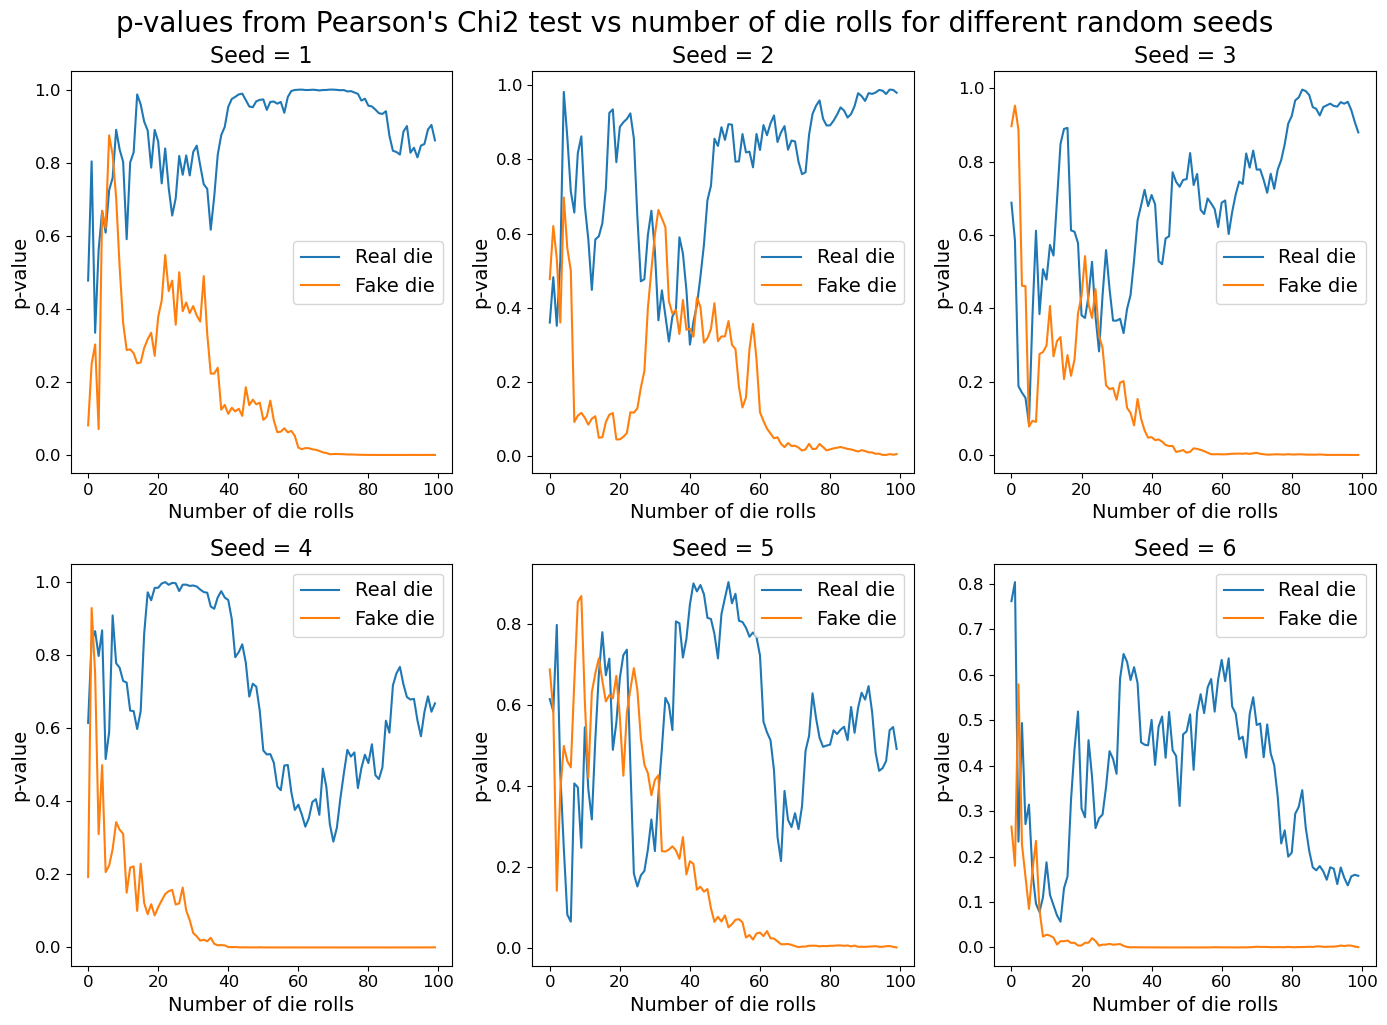

In [ ]:
nseeds = 6
fig, ax = plt.subplots(2, int(nseeds/2), figsize=(14, 10))
ax = ax.flatten()

for i, seed in enumerate(np.arange(nseeds)+1):
    preals, pfakes = tracingp_dies(seed, max_rolls=20)
    ax[i].plot(preals, '-', label='Real die')
    ax[i].plot(pfakes, '-', label='Fake die')
    ax[i].set_title(f"Seed = {seed}", fontsize=16)
    ax[i].set_xlabel("Number of die rolls", fontsize=14)
    ax[i].set_ylabel("p-value", fontsize=14)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].legend(fontsize=14);
plt.tight_layout();
plt.suptitle("p-values from Pearson's Chi2 test vs number of die rolls for different random seeds", fontsize=20, y=1.02);

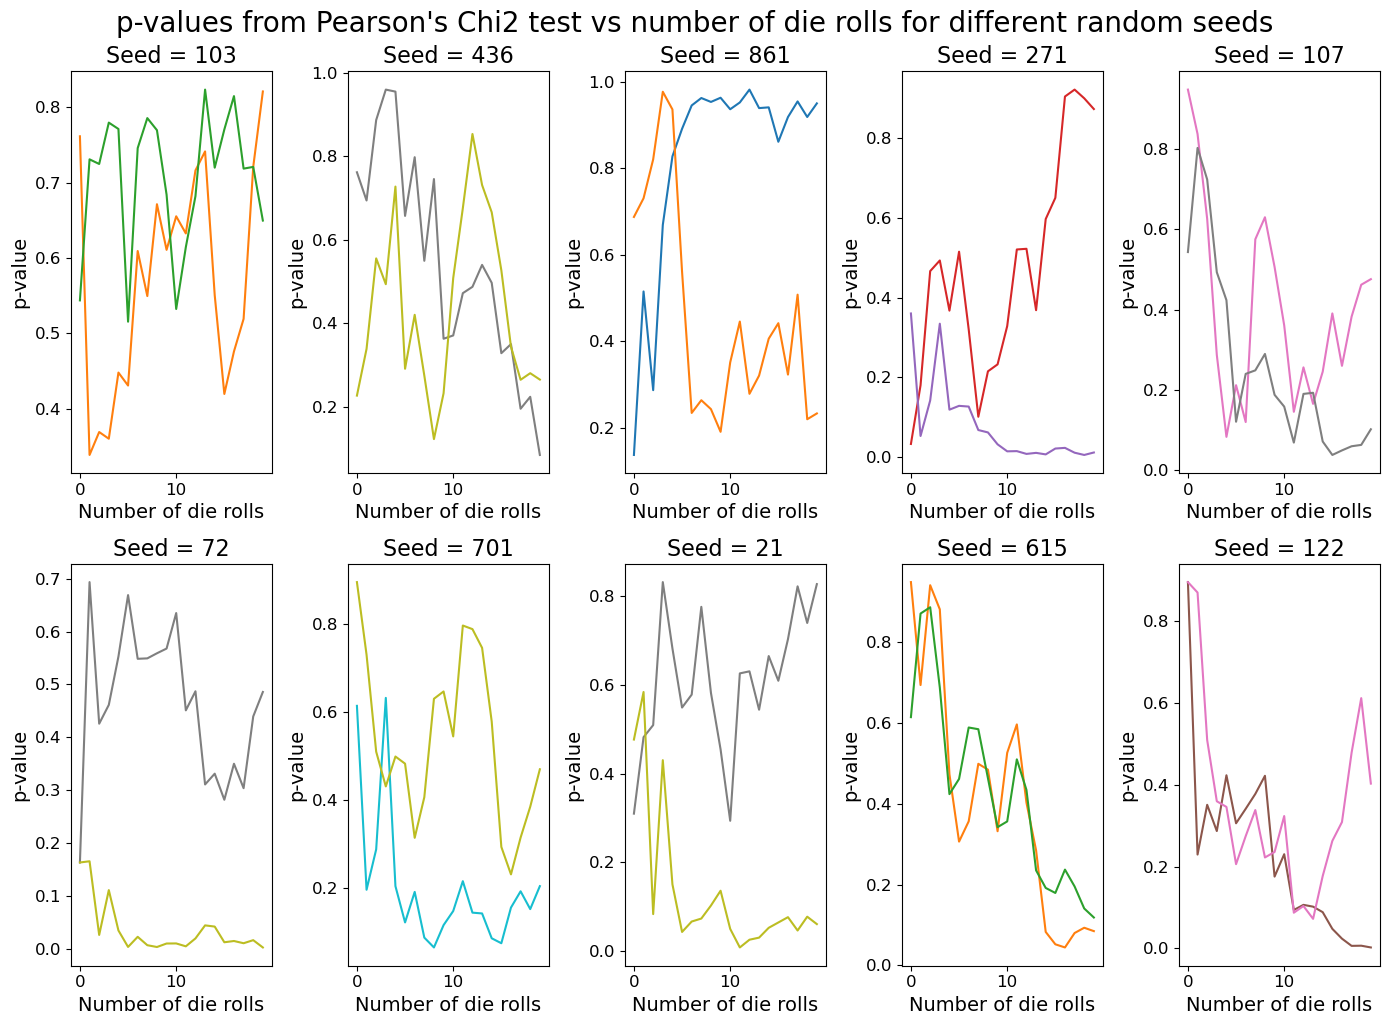

In [ ]:
r.seed(42)
seeds = r.randint(1, 1000, size=10)
fig, ax = plt.subplots(2, int(len(seeds)/2), figsize=(14, 10))
ax = ax.flatten()

for i, seed in enumerate(seeds):
    preals, pfakes = tracingp_dies(seed, max_rolls=20)
    c0 = r.randint(0,10)
    c1 = c0 + 1 if c0 < 9 else c0 -1
    ax[i].plot(preals, '-', c=f'C{c0}')
    ax[i].plot(pfakes, '-', c=f'C{c1}')
    ax[i].set_title(f"Seed = {seed}", fontsize=16)
    ax[i].set_xlabel("Number of die rolls", fontsize=14)
    ax[i].set_ylabel("p-value", fontsize=14)
    ax[i].tick_params(axis='both', labelsize=12)
plt.tight_layout();
plt.suptitle("p-values from Pearson's Chi2 test vs number of die rolls for different random seeds", fontsize=20, y=1.02);

In [ ]:
# rolls_needed_diff = []
# nseeds = 1000
# threshold = 0.1
# consec_count_needed = 10

# for seed in np.arange(nseeds):
#     preals, pfakes = tracingp_dies(seed, max_rolls=200)  # Your function returning lists/arrays
#     diff = preals - pfakes

#     consec_count = 0
#     for i, d in enumerate(diff):
#         if d > threshold:
#             consec_count += 1
#             if consec_count >= consec_count_needed:
#                 # Remove last index (i) and append it to rolls_needed
#                 rolls_needed_diff.append(i+1)
#                 if i>100:
#                     fig, ax = plt.subplots(figsize=(8, 6))
#                     ax.plot(preals, '-', label='Real die')
#                     ax.plot(pfakes, '-', label='Fake die')
#                     ax.set_title(f"Seed = {seed}", fontsize=16)
#                     ax.set_xlabel("Number of die rolls", fontsize=14)
#                     ax.set_ylabel("p-value", fontsize=14)
#                     ax.tick_params(axis='both', labelsize=12)
#                     ax.legend(fontsize=14);
#                 break  # Stop checking once condition is met
#         else :
#             consec_count = 0  # Reset if difference drops below threshold

In [ ]:
rolls_needed = []
nseeds = 1000
threshold_diff = 0.1
threshold_pfakes = 0.05
consec_count_needed = 10
pvals_special = []

for seed in np.arange(nseeds):
    preals, pfakes = tracingp_dies(seed, max_rolls=200)  # Your function returning lists/arrays
    diff = preals - pfakes

    consec_diff = 0
    consec_pfakes = 0
    first_index = None

    for i, (d, pf) in enumerate(zip(diff, pfakes)):
        # Check diff condition
        if d > threshold_diff:
            consec_diff += 1
        else:
            consec_diff = 0

        # Check pfakes condition
        if pf < threshold_pfakes:
            consec_pfakes += 1
        else:
            consec_pfakes = 0

        # If either condition met for required consecutive rolls
        if consec_diff >= consec_count_needed or consec_pfakes >= consec_count_needed:
            first_index = i+1  # Index of last in sequence
            if first_index>100:
                pvals_special.append((seed, preals, pfakes))
            break

    if first_index is not None:
        rolls_needed.append(first_index)


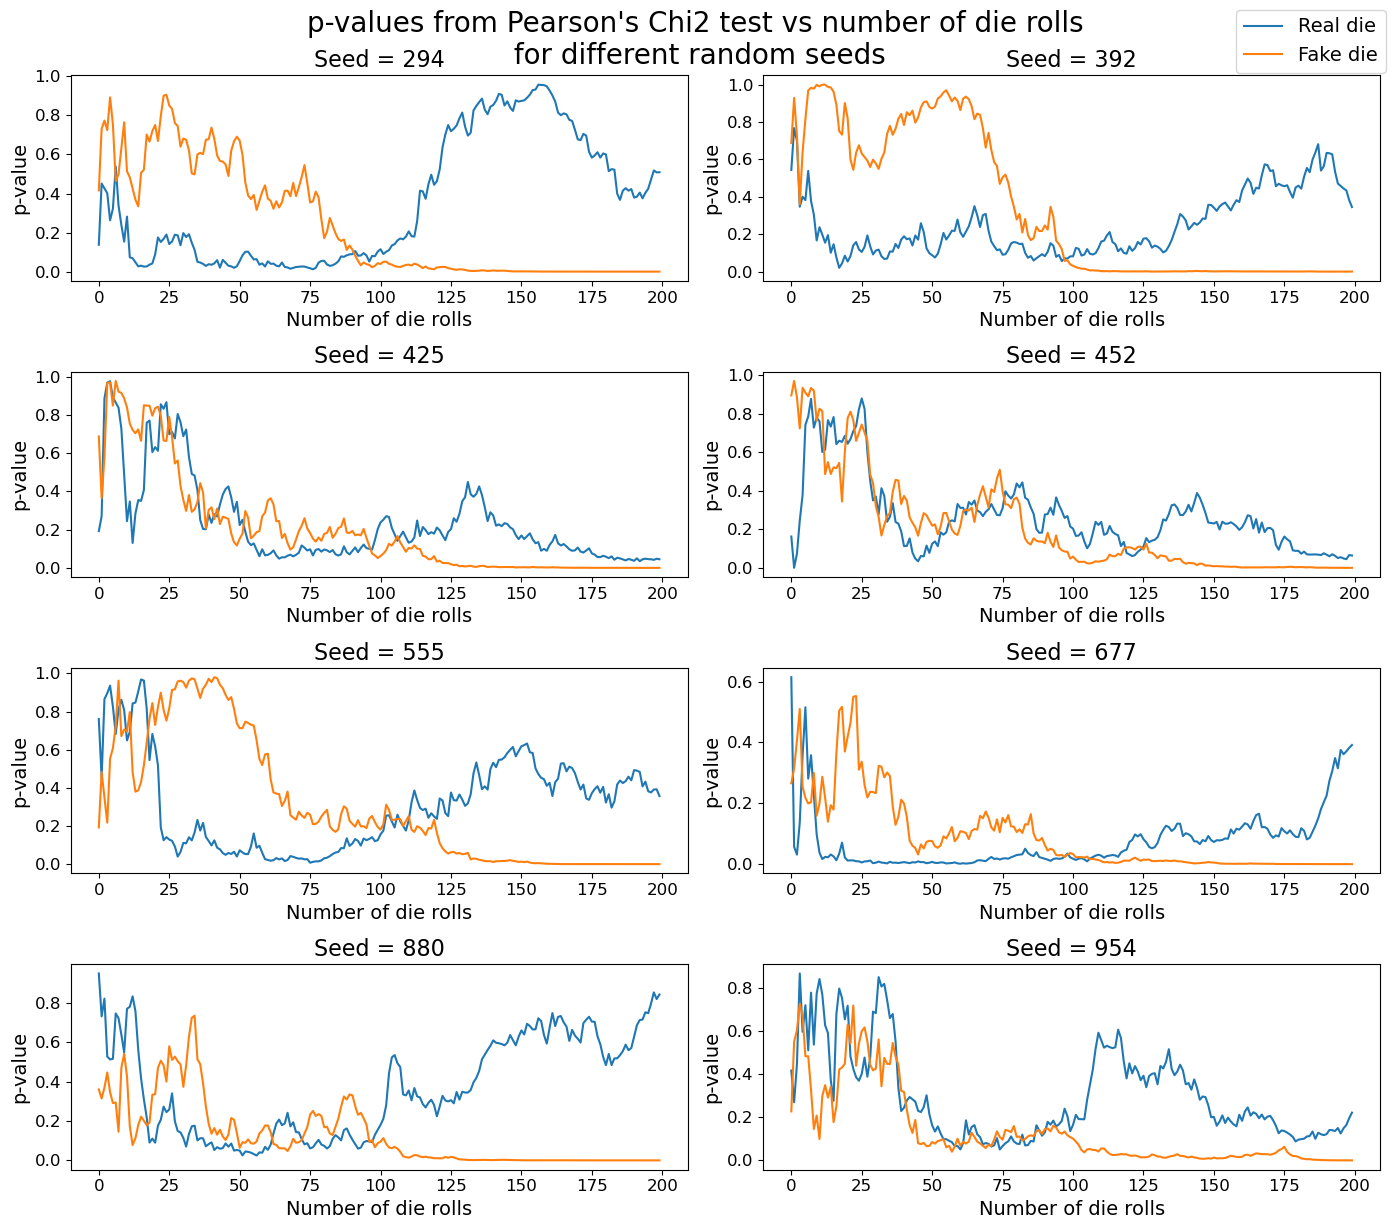

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=(14, 12))
ax = ax.flatten()

# Transpose using zip
seeds, reals, fakes = map(list, zip(*pvals_special))
for i in range(len(seeds)):
    ax[i].plot(reals[i], '-')
    ax[i].plot(fakes[i], '-')
    ax[i].set_title(f"Seed = {seeds[i]}", fontsize=16)
    ax[i].set_xlabel("Number of die rolls", fontsize=14)
    ax[i].set_ylabel("p-value", fontsize=14)
    ax[i].tick_params(axis='both', labelsize=12)
fig.legend(fontsize=14, loc='upper right', labels=['Real die', 'Fake die']);
plt.tight_layout();
plt.suptitle("p-values from Pearson's Chi2 test vs number of die rolls\n for different random seeds", fontsize=20, y=1.02);

131


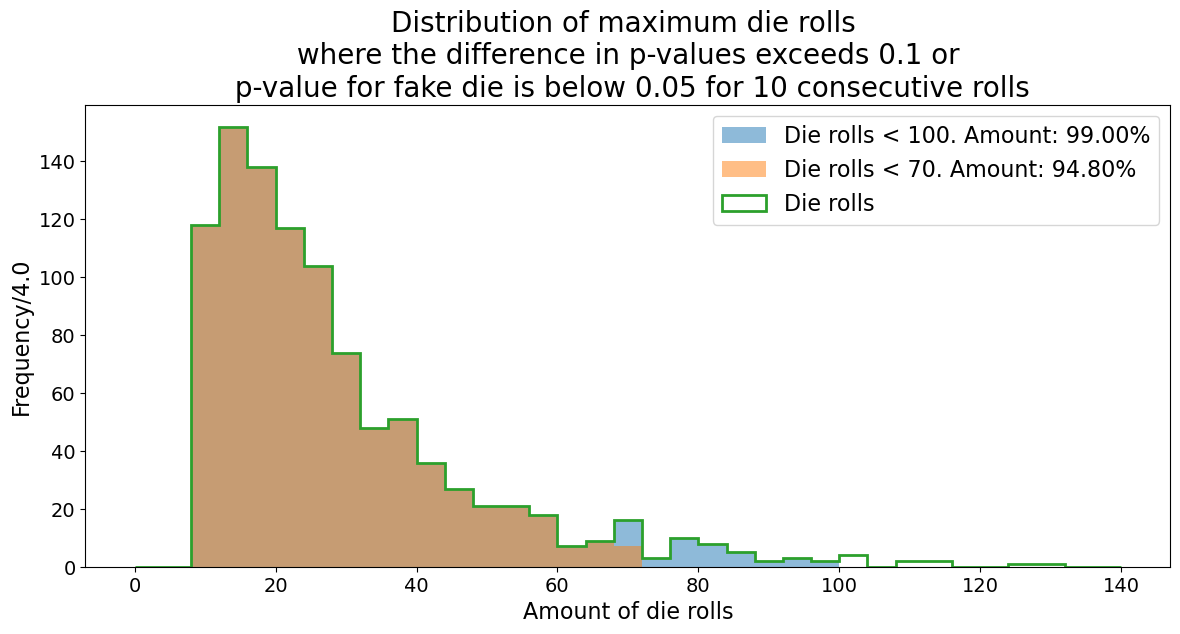

In [ ]:
xmin, xmax = 0, 140
N_bins = 35
binwidth = (xmax - xmin)/N_bins
rolls_needed = np.array(rolls_needed)
print(np.max(rolls_needed))
limit_1 = 100
within_1 = rolls_needed[rolls_needed < limit_1]
amount_1 = len(within_1)/len(rolls_needed)

limit_5 = 70
within_5 = rolls_needed[rolls_needed < limit_5]
amount_5 = len(within_5)/len(rolls_needed)

fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(within_1, bins=N_bins, range=(xmin, xmax), histtype='bar', linewidth=2, alpha=0.5, label=f'Die rolls < {limit_1}. Amount: {amount_1*100:.2f}%')
ax.hist(within_5, bins=N_bins, range=(xmin, xmax), histtype='bar', linewidth=2, alpha=0.5, label=f'Die rolls < {limit_5}. Amount: {amount_5*100:.2f}%')
# ax.hist(rolls_needed_diff, bins=N_bins, range=(xmin, xmax), histtype='step', linewidth=2, label='Max die rolls (diff > 0.1)')
ax.hist(rolls_needed, bins=N_bins, range=(xmin, xmax), histtype='step', linewidth=2, label='Die rolls')
ax.set_xlabel("Amount of die rolls", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth}", fontsize=16)
ax.set_title("Distribution of maximum die rolls \n where the difference in p-values exceeds 0.1 or \n p-value for fake die is below 0.05 for 10 consecutive rolls", fontsize=20)
ax.tick_params(axis='both', labelsize=14)
ax.legend(loc='best', fontsize=16);

# Problem V - Fitting data

## 5.1

In [114]:
def gauss(x, N, mu, sigma):
    return N * stats.norm.pdf(x, mu, sigma)

def exp_pdf(x, N_exp, tau):
    return N_exp * 1.0 / tau * np.exp(-x/tau)


In [115]:
dataframe = pd.read_csv('Data/data_InconstantBackground.csv', header=0)
distance = dataframe['# Distance']

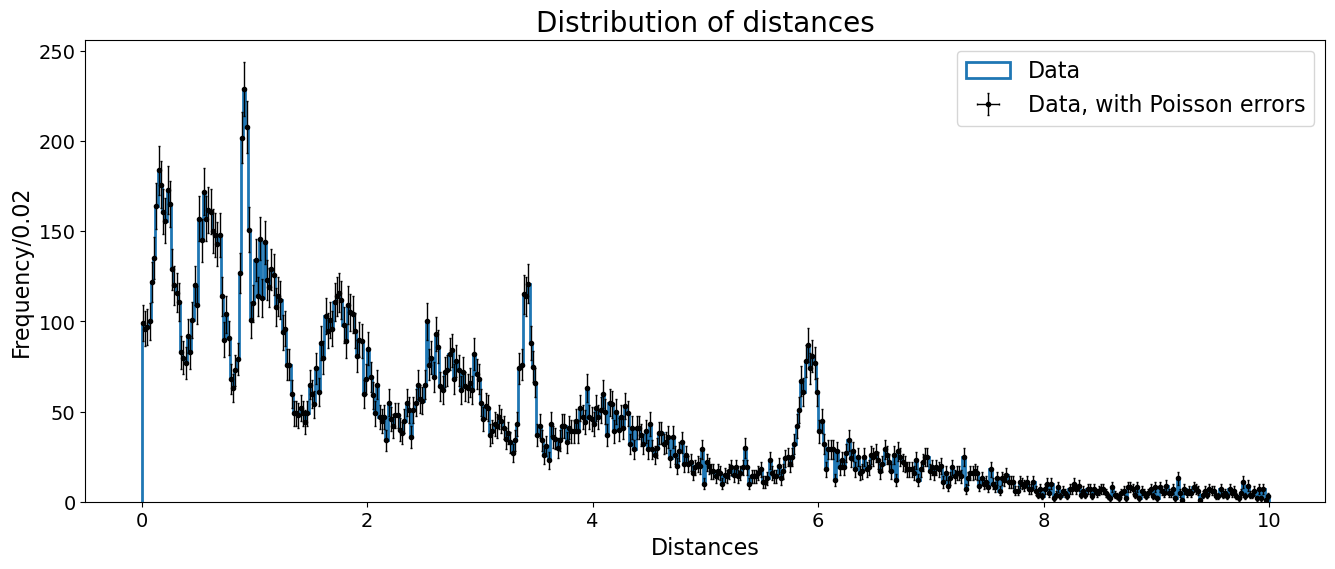

In [116]:
xmin, xmax = 0, 10
N_bins = 500
binwidth = (xmax - xmin)/N_bins

fig, ax = plt.subplots(figsize=(16, 6))
ax.hist(distance, bins=N_bins, range=(xmin, xmax), histtype='step', linewidth=2, label='Data')
counts, bin_edges = np.histogram(distance, bins=N_bins, range=(xmin, xmax))
x = (bin_edges[1:] + bin_edges[:-1])/2
y = counts    
sy = np.sqrt(counts) 
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

ax.set_xlabel("Distances", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth:.2f}", fontsize=16)
ax.set_title("Distribution of distances", fontsize=20)
ax.tick_params(axis='both', labelsize=14)
ax.legend(loc='best', fontsize=16);

### Uniform?

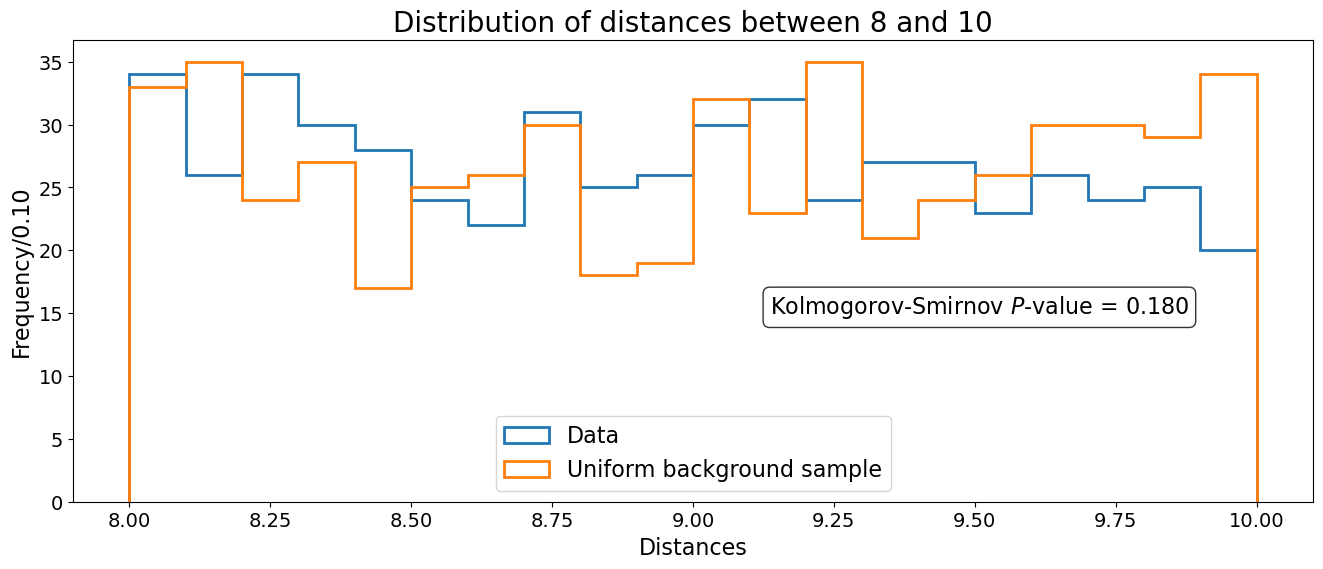

In [117]:
r.seed(42)
xmin_bkg, xmax_bkg = 8, 10
N_bins = 20
binwidth = (xmax_bkg - xmin_bkg)/N_bins

distance_bkg= distance[distance > 8]
uniform_bkg = r.uniform(8, 10, size=len(distance_bkg))

p_ks = stats.ks_2samp(distance_bkg, uniform_bkg)[1]

fig, ax = plt.subplots(figsize=(16, 6))
ax.hist(distance_bkg, bins=N_bins, range=(xmin_bkg, xmax_bkg), histtype='step', linewidth=2, label='Data')
ax.hist(uniform_bkg, bins=N_bins, range=(xmin_bkg, xmax_bkg), histtype='step', linewidth=2, label='Uniform background sample')

fit_info = [f"Kolmogorov-Smirnov $P$-value = {p_ks:.3f}",]
# Put fit info as a text box inside the plot
ax.text(
    0.9, 0.45,
    "\n".join(fit_info),
    transform=ax.transAxes,
    fontsize=16,
    va='top', ha='right',
    bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.8)
)

ax.set_xlabel("Distances", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth:.2f}", fontsize=16)
ax.set_title("Distribution of distances between 8 and 10", fontsize=20)
ax.tick_params(axis='both', labelsize=14)
ax.legend(loc='best', fontsize=16);

### Fit

In [118]:
def peak3a(x, N1, mu1, sigma1, N2, mu2, sigma2):
    return (gauss(x, N1, mu1, sigma1) + gauss(x, N2, mu2, sigma2))

def peak2(x, N1, mu1, sigma1, N2, a, b, c):
    return (gauss(x, N1, mu1, sigma1) + N2*(a*x**2 + b*x + c))

def peak3b(x, N1, mu1, sigma1, N2, a, b):
    return (gauss(x, N1, mu1, sigma1) + N2*(a*x + b))

In [119]:
mask2 = (x > 3) & (x < 4)
mask3 = (x > 5) & (x < 7)


cfit3 = cost.LeastSquares(x[mask3], y[mask3], sy[mask3], peak3a)
mfit3 = Minuit(cfit3, N1=50, mu1=5.9, sigma1=0.1, N2=20, mu2=6.5, sigma2=0.5)
mfit3.migrad();

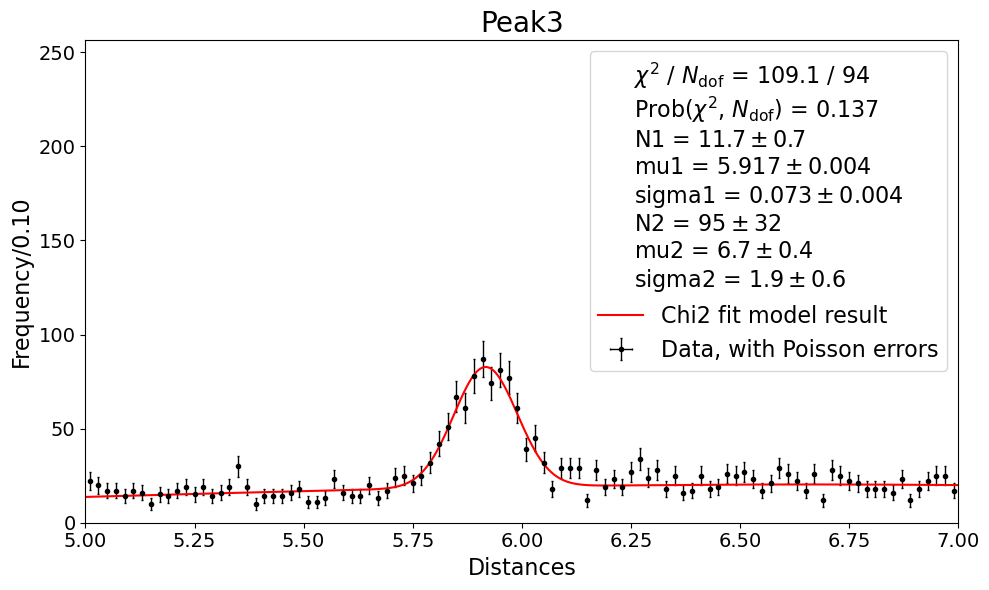

In [120]:
# Create just a single figure and axes, along with a histogram with uncertainties:
fig_chi2, ax_chi2 = plt.subplots(figsize=(10, 6))  # figsize is in inches
ax_chi2.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
# hist = ax.hist(x_all, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2, color='blue', label='Data, normal histogram')

ax_chi2.set_xlabel("Distances", fontsize=16)
ax_chi2.set_ylabel(f"Frequency/{binwidth:.2f}", fontsize=16)
ax_chi2.set_title("Peak3", fontsize=20)
ax_chi2.tick_params(axis='both', labelsize=14)
ax_chi2.set_ylim([0.0,None]) # Setting the miminum to zero
ax_chi2.set_xlim([5, 7])

# Adding fit function to plot:
x_axis3 = np.linspace(5, 7, 1000)
ax_chi2.plot(x_axis3, peak3a(x_axis3, *mfit3.values[:]), '-r', label= r"Chi2 fit model result") 

# Adding fit results to plot:
chi2 = mfit3.fval                     # ChiSquare value
Ndof = len(x[mask3]) - mfit3.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit3.parameters, mfit3.values[:], mfit3.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');
fig_chi2.tight_layout()

In [121]:
cfit2 = cost.LeastSquares(x[mask2], y[mask2], sy[mask2], peak2)
mfit2 = Minuit(cfit2, N1=30, mu1=3.4, sigma1=0.05, N2=1, a=0, b=0, c=0)
mfit2.migrad();

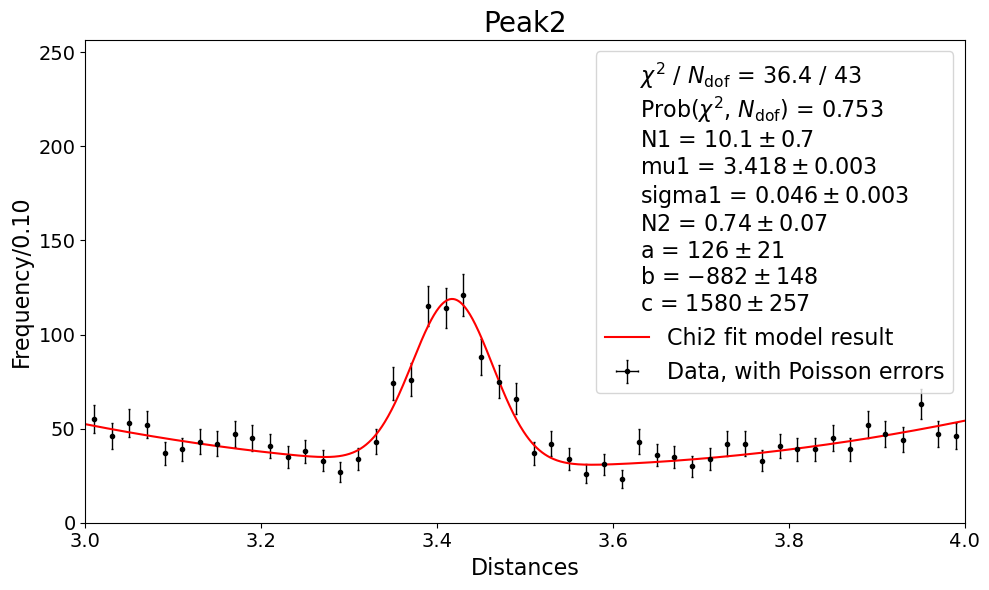

In [122]:
# Create just a single figure and axes, along with a histogram with uncertainties:
fig_chi2, ax_chi2 = plt.subplots(figsize=(10, 6))  # figsize is in inches
ax_chi2.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
# hist = ax.hist(x_all, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2, color='blue', label='Data, normal histogram')

ax_chi2.set_xlabel("Distances", fontsize=16)
ax_chi2.set_ylabel(f"Frequency/{binwidth:.2f}", fontsize=16)
ax_chi2.set_title("Peak2", fontsize=20)
ax_chi2.tick_params(axis='both', labelsize=14)
ax_chi2.set_ylim([0.0,None]) # Setting the miminum to zero
ax_chi2.set_xlim([3, 4])

# Adding fit function to plot:
x_axis2 = np.linspace(3, 4, 1000)
ax_chi2.plot(x_axis2, peak2(x_axis2, *mfit2.values[:]), '-r', label= r"Chi2 fit model result") 
# Adding fit results to plot:
chi2 = mfit2.fval                     # ChiSquare value
Ndof = len(x[mask2]) - mfit2.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit2.parameters, mfit2.values[:], mfit2.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');
fig_chi2.tight_layout()

In [123]:
def peak1(x, N1, mu1, sigma1, N2, a, b):
    return (gauss(x, N1, mu1, sigma1) + N2*(a*x + b))

In [124]:
mask1 = (x > 0.8) & (x < 1.1)

cfit1 = cost.LeastSquares(x[mask1], y[mask1], sy[mask1], peak1)
mfit1 = Minuit(cfit1, N1=300, mu1=0.9, sigma1=0.01, N2=100, a=0, b=0)
mfit1.migrad();

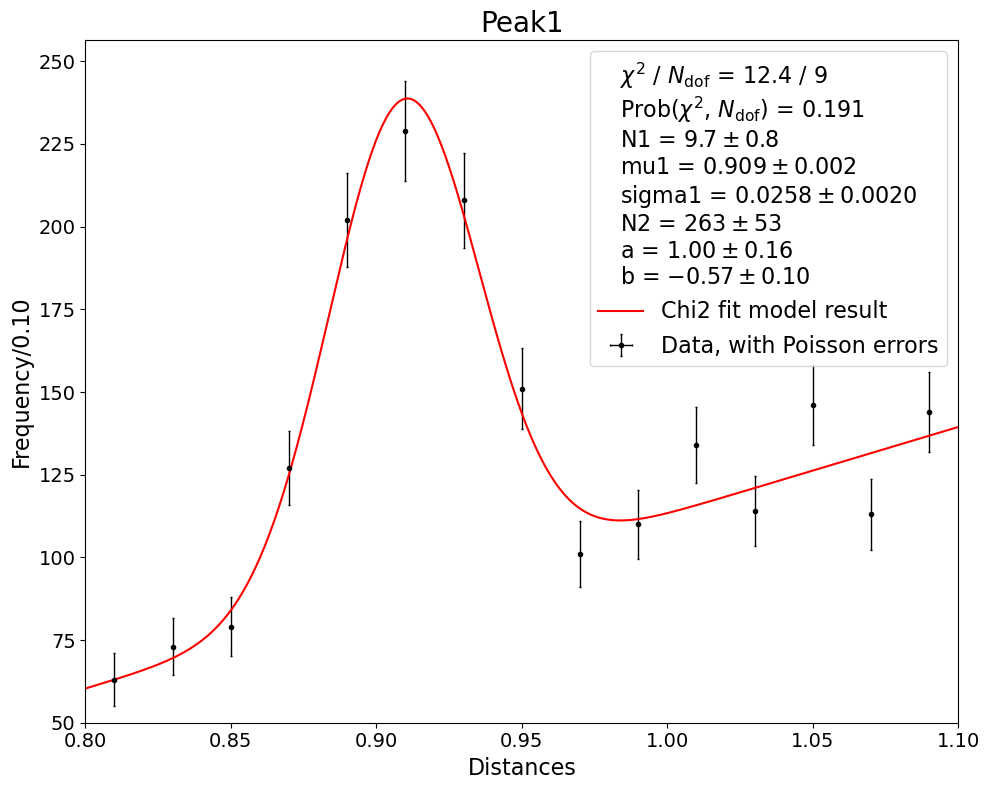

In [125]:
# Create just a single figure and axes, along with a histogram with uncertainties:
fig_chi2, ax_chi2 = plt.subplots(figsize=(10, 8))  # figsize is in inches
ax_chi2.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
# hist = ax.hist(x_all, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2, color='blue', label='Data, normal histogram')

ax_chi2.set_xlabel("Distances", fontsize=16)
ax_chi2.set_ylabel(f"Frequency/{binwidth:.2f}", fontsize=16)
ax_chi2.set_title("Peak1", fontsize=20)
ax_chi2.tick_params(axis='both', labelsize=14)
ax_chi2.set_ylim([50,None]) # Setting the miminum to zero
ax_chi2.set_xlim([0.8, 1.1])

# Adding fit function to plot:
x_axis1 = np.linspace(0.8, 1.1, 1000)
ax_chi2.plot(x_axis1, peak1(x_axis1, *mfit1.values[:]), '-r', label= r"Chi2 fit model result") 
# Adding fit results to plot:
chi2 = mfit1.fval                     # ChiSquare value
Ndof = len(x[mask1]) - mfit1.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit1.parameters, mfit1.values[:], mfit1.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');
fig_chi2.tight_layout()

In [126]:
N_vals = np.array([mfit1.values['N1'], mfit2.values['N1'], mfit3.values['N1']])
e_N_vals = np.array([mfit1.errors['N1'], mfit2.errors['N1'], mfit3.errors['N1']])
mean, _ = weighted_mean(N_vals, e_N_vals)
chi2 = np.sum(((N_vals - mean) / e_N_vals) ** 2)
ndof = len(N_vals) - 1
Prob = stats.chi2.sf(chi2, ndof)
print(f"Chi2/ndof = {chi2:.1f}/{ndof}, Prob = {Prob:.3f}")
for i in range(len(N_vals)):
    z = np.abs(N_vals[i] - N_vals[(i+1)%3]) / np.sqrt(e_N_vals[i]**2 + e_N_vals[(i+1)%3]**2)
    p = 2*stats.norm.sf(z)
    # print(f"z-value between Distance {i+1} and Distance {(i+2)%3}: {z:.2f}")
    print(f"p-value between Intensity {i+1} and Intensity {(i+2)%3}: {p:.2f}")

Chi2/ndof = 3.9/2, Prob = 0.144
p-value between Intensity 1 and Intensity 2: 0.65
p-value between Intensity 2 and Intensity 0: 0.12
p-value between Intensity 3 and Intensity 1: 0.07


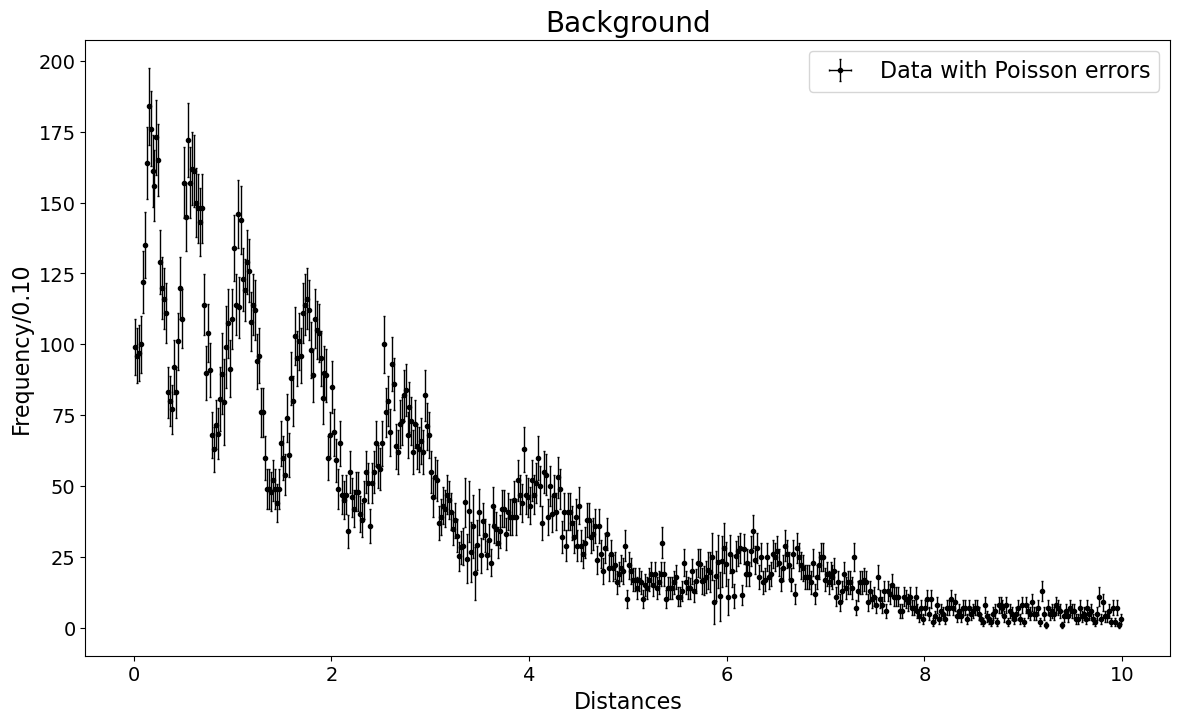

In [127]:
y_new = y - gauss(x, *mfit1.values[:3]) - gauss(x, *mfit2.values[:3]) - gauss(x, *mfit3.values[:3])
fig, ax = plt.subplots(figsize=(14, 8))
ax.errorbar(x, y_new, yerr=sy, xerr=0.0, label='Data with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
ax.set_xlabel("Distances", fontsize=16)
ax.set_ylabel(f"Frequency/{binwidth:.2f}", fontsize=16)
ax.set_title("Background", fontsize=20)
ax.legend(loc='best', fontsize=16)
ax.tick_params(axis='both', labelsize=14);

In [128]:
def background_gauss(x, *params):
    n_gauss = (len(params) - 2) // 3
    Ns     = params[0:n_gauss]
    mus    = params[n_gauss:2*n_gauss]
    sigmas = params[2*n_gauss:3*n_gauss]
    N_exp, tau = params[-2:]

    total = np.zeros_like(x, dtype=float)
    for N, mu, sigma in zip(Ns, mus, sigmas):
        total += N * stats.norm.pdf(x, mu, sigma)

    return total + exp_pdf(x, N_exp, tau)

In [129]:
cfit_gauss = cost.LeastSquares(x, y_new, sy, background_gauss)
# 7 Gaussians
Ns_guess     = [37, 45, 50, 50, 50, 50, 50]
mus_guess    = [0.2, 0.6, 1.1, 1.8, 2.7, 4.1, 6.5]
sigmas_guess = [0.08, 0.08, 0.1, 0.12, 0.16, 0.18, 1]

# exponential
N_exp_guess = 1000
tau_guess   = 3

# flatten into a single list
p0 = Ns_guess + mus_guess + sigmas_guess + [N_exp_guess, tau_guess]

mfit_gauss = Minuit(cfit_gauss, *p0)
mfit_gauss.migrad();

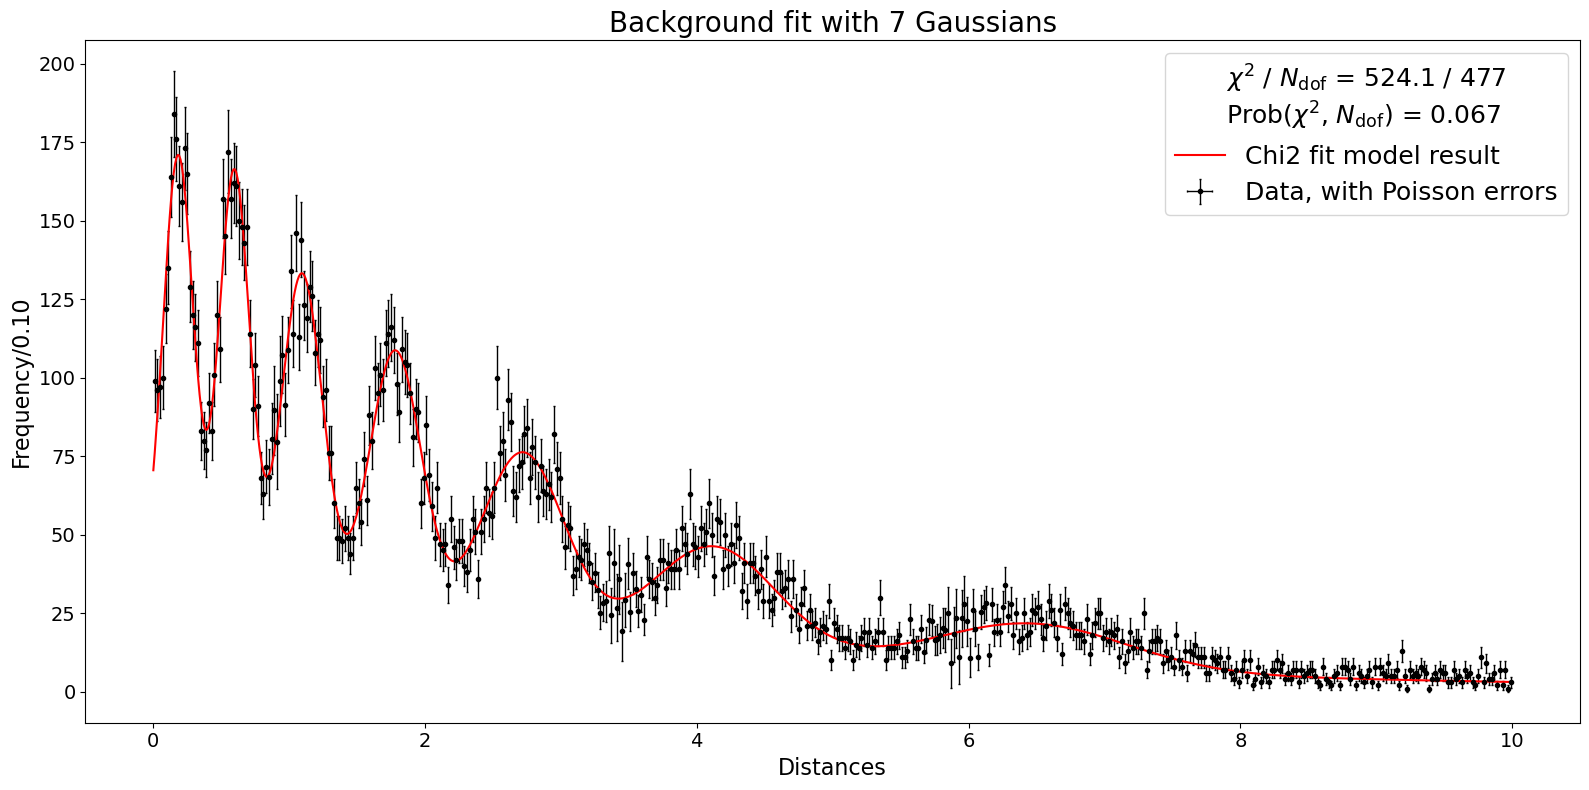

In [130]:
# Create just a single figure and axes, along with a histogram with uncertainties:
fig_chi2, ax_chi2 = plt.subplots(figsize=(16, 8))  # figsize is in inches
ax_chi2.errorbar(x, y_new, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
# hist = ax.hist(x_all, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2, color='blue', label='Data, normal histogram')

ax_chi2.set_xlabel("Distances", fontsize=16)
ax_chi2.set_ylabel(f"Frequency/{binwidth:.2f}", fontsize=16)
ax_chi2.set_title("Background fit with 7 Gaussians", fontsize=20)
ax_chi2.tick_params(axis='both', labelsize=14)
#ax_chi2.set_xticks(np.linspace(xmin, xmax, 21))

# Adding fit function to plot:
x_axis = np.linspace(xmin, xmax, 1000)
ax_chi2.plot(x_axis, background_gauss(x_axis, *mfit_gauss.values[:]), '-r', label= r"Chi2 fit model result") 

# Adding fit results to plot:
chi2 = mfit_gauss.fval                     # ChiSquare value
Ndof = len(x[y_new > 0]) - mfit_gauss.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]

plt.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18, alignment = 'center');
fig_chi2.tight_layout()

In [131]:
def background_sine(t, N_exp, A, tau, omega0, alpha, beta, phi):
    instantaneous_omega = omega0 / (1 + alpha * t)
    oscillation = A*np.sin(instantaneous_omega * t+phi) * np.exp(-beta * t)
    return oscillation + N_exp*np.exp(-t/tau)

In [132]:
# cfit_sine = cost.LeastSquares(x, y_new, sy, background_sine)
# mfit_sine = Minuit(cfit_sine, N_exp=143, A=52, tau1=0.1, tau2=0.5, omega0=15, alpha=0.2, beta=0.1, phi=0)
# mfit_sine.migrad();

cfit_sine = cost.LeastSquares(x, y_new, sy, background_sine)
mfit_sine = Minuit(cfit_sine, N_exp=143, A=52, tau=0.5, omega0=15, alpha=0.2, beta=0.1, phi=0)
mfit_sine.migrad();

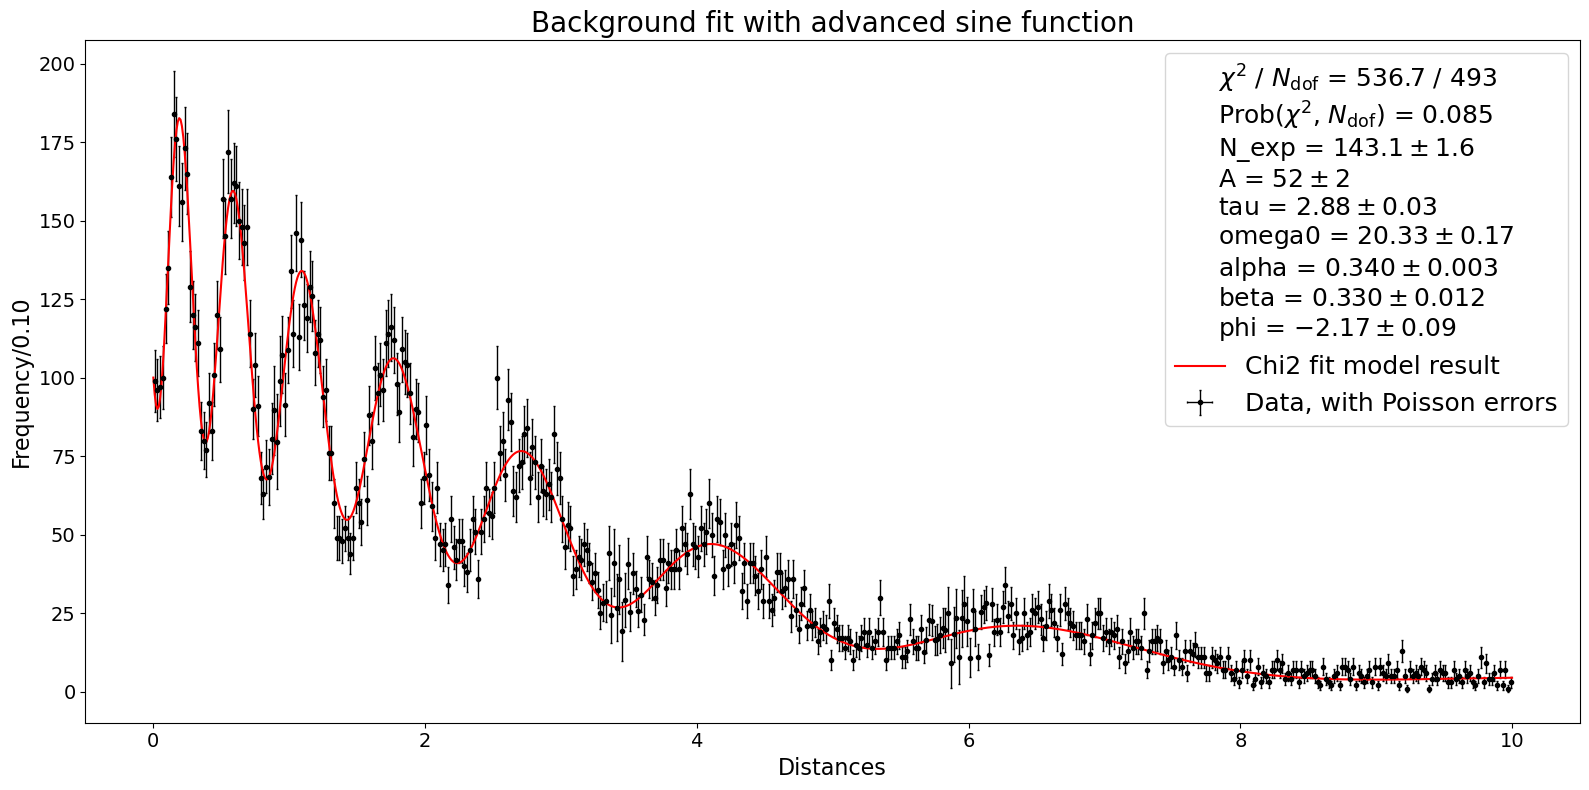

In [133]:
# Create just a single figure and axes, along with a histogram with uncertainties:
fig_chi2, ax_chi2 = plt.subplots(figsize=(16, 8))  # figsize is in inches
ax_chi2.errorbar(x, y_new, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
# hist = ax.hist(x_all, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2, color='blue', label='Data, normal histogram')

ax_chi2.set_xlabel("Distances", fontsize=16)
ax_chi2.set_ylabel(f"Frequency/{binwidth:.2f}", fontsize=16)
ax_chi2.set_title("Background fit with advanced sine function", fontsize=20)
ax_chi2.tick_params(axis='both', labelsize=14)
# ax_chi2.set_xticks(np.linspace(xmin, xmax, 21))

# Adding fit function to plot:
x_axis = np.linspace(xmin, xmax, 1000)
ax_chi2.plot(x_axis, background_sine(x_axis, *mfit_sine.values[:]), '-r', label= r"Chi2 fit model result") 

# Adding fit results to plot:
chi2 = mfit_sine.fval                     # ChiSquare value
Ndof = len(x[y_new > 0]) - mfit_sine.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit_sine.parameters, mfit_sine.values[:], mfit_sine.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18, alignment = 'center');
fig_chi2.tight_layout()

In [134]:
def full_fit(t, N_exp, A, tau, omega0, alpha, beta, phi, N1, mu1, sigma1, N2, mu2, sigma2, N3, mu3, sigma3):
    background_sine_part = background_sine(t, N_exp, A, tau, omega0, alpha, beta, phi)
    gauss1 = gauss(t, N1, mu1, sigma1)
    gauss2 = gauss(t, N2, mu2, sigma2)
    gauss3 = gauss(t, N3, mu3, sigma3)
    return background_sine_part + gauss1 + gauss2 + gauss3

In [135]:
cfit = cost.LeastSquares(x, y, sy, full_fit)

mfit = Minuit(cfit, N_exp=143, A=52, tau=2.88, omega0=20.33, alpha=0.340, beta=0.33, phi=-2.17, N1= 11.7, mu1=5.917, sigma1=0.0073, N2=10.1, mu2=3.418, sigma2=0.046, N3=9.7, mu3=0.909, sigma3=0.1)
mfit.migrad();

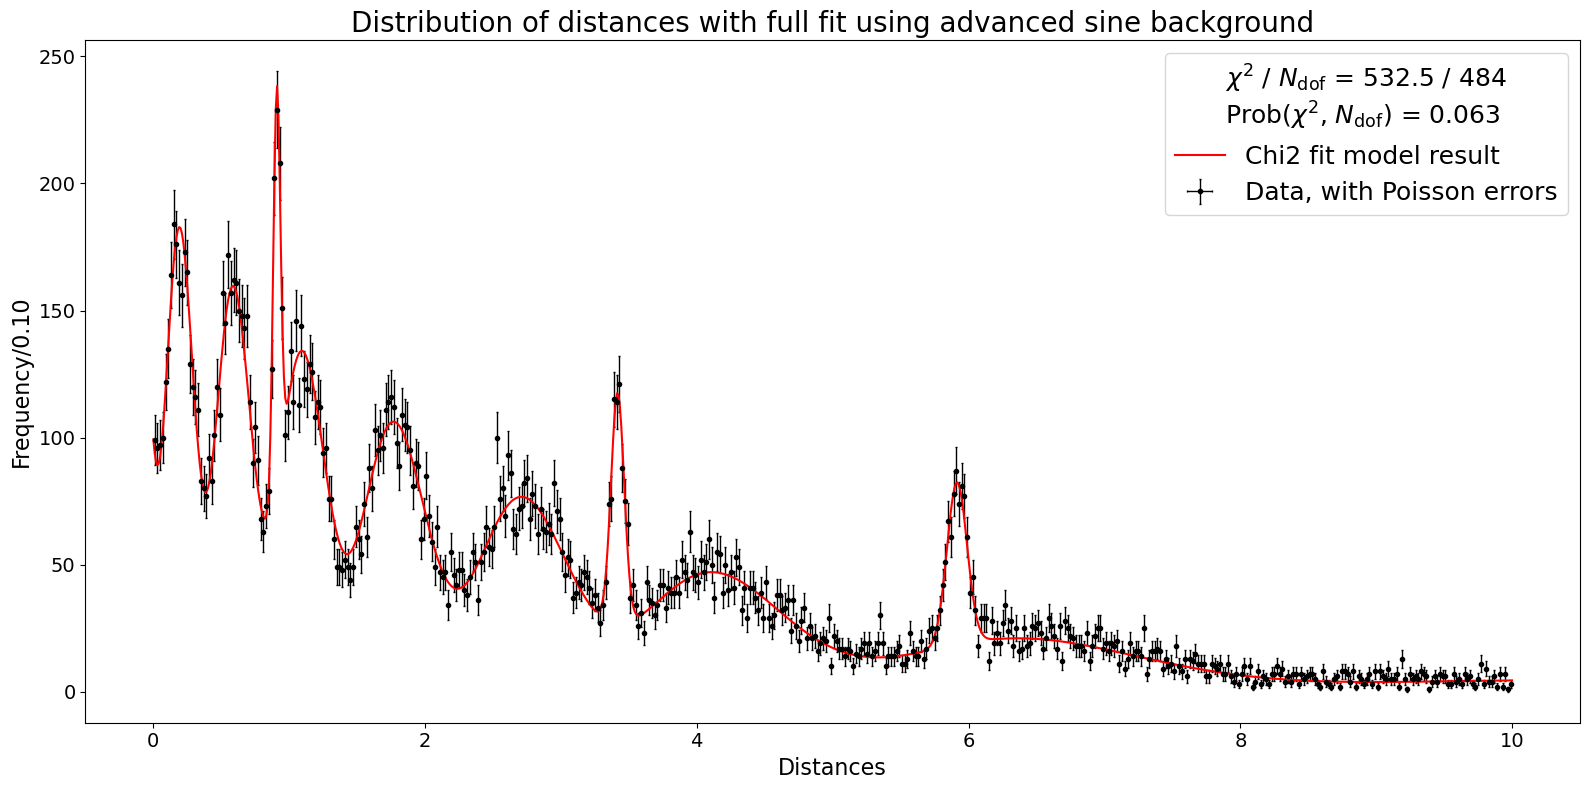

In [136]:
# Create just a single figure and axes, along with a histogram with uncertainties:
fig_chi2, ax_chi2 = plt.subplots(figsize=(16, 8))  # figsize is in inches
ax_chi2.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
# hist = ax.hist(x_all, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2, color='blue', label='Data, normal histogram')

ax_chi2.set_xlabel("Distances", fontsize=16)
ax_chi2.set_ylabel(f"Frequency/{binwidth:.2f}", fontsize=16)
ax_chi2.set_title("Distribution of distances with full fit using advanced sine background", fontsize=20)
ax_chi2.tick_params(axis='both', labelsize=14)

# Adding fit function to plot:
x_axis = np.linspace(xmin, xmax, 1000)
ax_chi2.plot(x_axis, full_fit(x_axis, *mfit.values[:]), '-r', label= r"Chi2 fit model result") 

# Adding fit results to plot:
chi2 = mfit.fval                     # ChiSquare value
Ndof = len(x[y > 0]) - mfit.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]

plt.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18, alignment = 'center');
fig_chi2.tight_layout()

In [137]:
cfit_gauss_full = cost.LeastSquares(x, y, sy, background_gauss)
# 7 Gaussians
Ns_guess = mfit_gauss.values[0:7] + [11.7, 10.1, 9.7]
mus_guess = mfit_gauss.values[7:14] + [5.917, 3.418, 0.909]
sigmas_guess =  mfit_gauss.values[14:21] + [0.0073, 0.046, 0.026]


# exponential
N_exp_guess = mfit_gauss.values[-2]
tau_guess   = mfit_gauss.values[-1]

# flatten into a single list
p0 = Ns_guess + mus_guess + sigmas_guess + [N_exp_guess, tau_guess]

mfit_gauss_full = Minuit(cfit_gauss_full, *p0)
mfit_gauss_full.migrad();

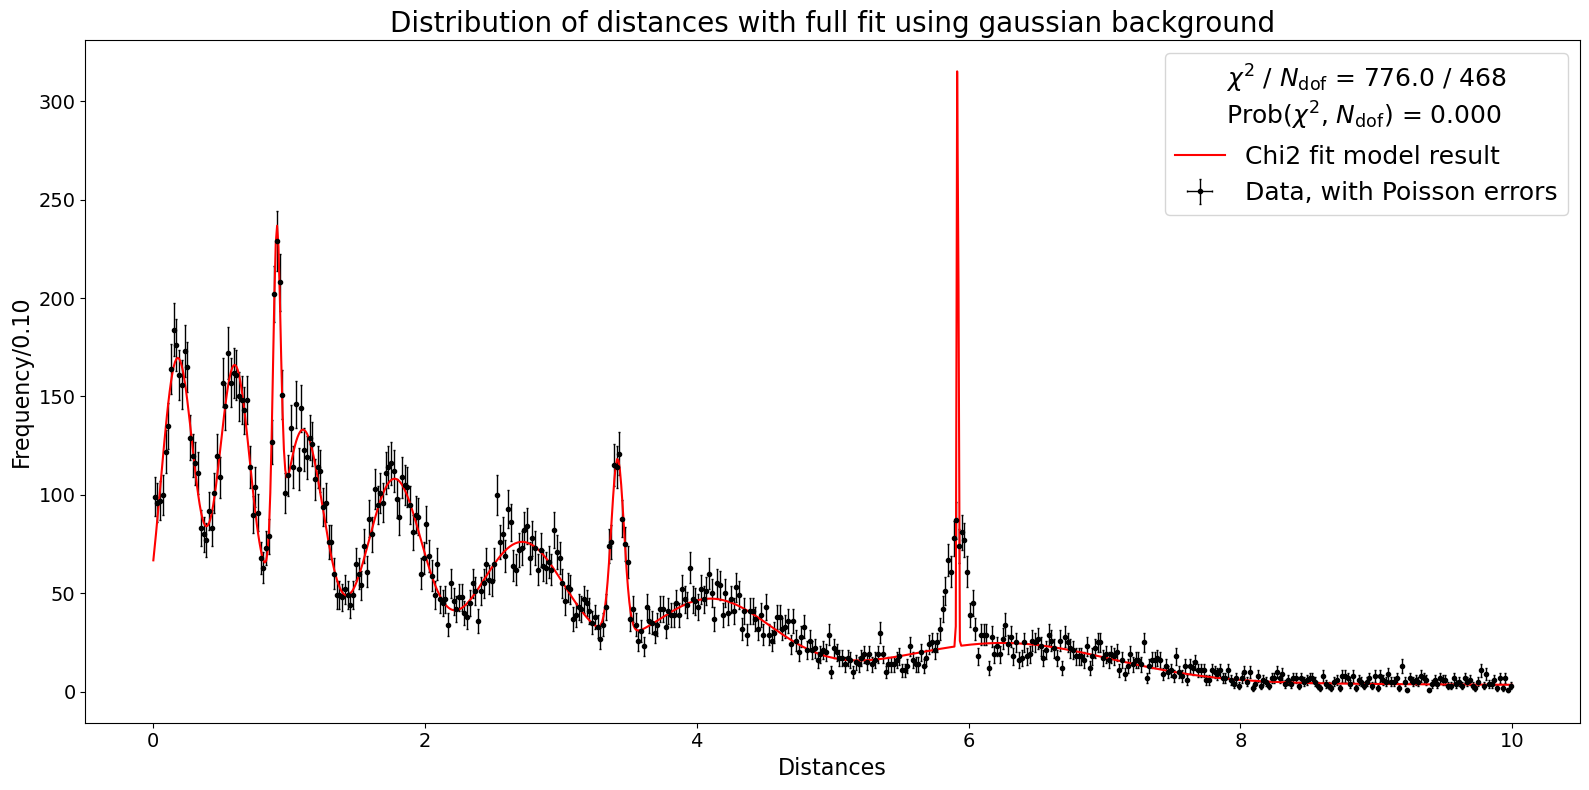

In [138]:
# Create just a single figure and axes, along with a histogram with uncertainties:
fig_chi2, ax_chi2 = plt.subplots(figsize=(16, 8))  # figsize is in inches
ax_chi2.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
# hist = ax.hist(x_all, bins=Nbins, range=(xmin, xmax), histtype='step', linewidth=2, color='blue', label='Data, normal histogram')

ax_chi2.set_xlabel("Distances", fontsize=16)
ax_chi2.set_ylabel(f"Frequency/{binwidth:.2f}", fontsize=16)
ax_chi2.set_title("Distribution of distances with full fit using gaussian background", fontsize=20)
ax_chi2.tick_params(axis='both', labelsize=14)

# Adding fit function to plot:
x_axis = np.linspace(xmin, xmax, 1000)
ax_chi2.plot(x_axis, background_gauss(x_axis, *mfit_gauss_full.values[:]), '-r', label= r"Chi2 fit model result") 

# Adding fit results to plot:
chi2 = mfit_gauss_full.fval                     # ChiSquare value
Ndof = len(x[y > 0]) - mfit_gauss_full.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]

plt.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18, alignment = 'center');
fig_chi2.tight_layout()

## 5.2

In [139]:
names = np.array(['Meidum', 'Bent', 'Red', 'Khufu', 'Khafre', 'Menk', 'Sahure', 'Nefer'])
year = np.array([2600, 2583, 2572, 2554, 2522, 2489, 2446, 2433])
east = np.array([-20.6, -17.3, -8.7, -3.4, 6, 12.4, 23, 30])
eeast = np.array([1, 0.2, 0.2, 0.2, 0.2, 1, 10, 10])
eeast1 = np.copy(eeast)
west = np.array([-18.1, -11.8, nan, -2.8, 6, 14.1, nan, nan])
ewest = np.array([1, 0.2, nan, 0.2, 0.2, 1.8, nan, nan])
for i in range(len(names)):
    if west[i] != nan:
        z = np.abs(east[i] - west[i])/np.sqrt(eeast[i]**2 + ewest[i]**2)
        p = stats.norm.sf(z)*2
        print(f"Pyramid {names[i]}: Z = {z:.2f}, p-value = {p:.4f}")
    else:
        print(f"Pyramid {names[i]}: only east alignment available.")

Pyramid Meidum: Z = 1.77, p-value = 0.0771
Pyramid Bent: Z = 19.45, p-value = 0.0000
Pyramid Red: only east alignment available.
Pyramid Khufu: Z = 2.12, p-value = 0.0339
Pyramid Khafre: Z = 0.00, p-value = 1.0000
Pyramid Menk: Z = 0.83, p-value = 0.4090
Pyramid Sahure: only east alignment available.
Pyramid Nefer: only east alignment available.


In [140]:
eeast = np.array([1, 2, 0.2, 0.3, 0.2, 1, 10, 10])
eeast2 = np.copy(eeast)
ewest = np.array([1, 2, nan, 0.3, 0.2, 1.8, nan, nan])
for i in range(len(names)):
    if west[i] != nan:
        z = np.abs(east[i] - west[i])/np.sqrt(eeast[i]**2 + ewest[i]**2)
        p = stats.norm.sf(z)*2
        print(f"Pyramid {names[i]}: Z = {z:.2f}, p-value = {p:.4f}")
    else:
        print(f"Pyramid {names[i]}: only east alignment available.")

Pyramid Meidum: Z = 1.77, p-value = 0.0771
Pyramid Bent: Z = 1.94, p-value = 0.0518
Pyramid Red: only east alignment available.
Pyramid Khufu: Z = 1.41, p-value = 0.1573
Pyramid Khafre: Z = 0.00, p-value = 1.0000
Pyramid Menk: Z = 0.83, p-value = 0.4090
Pyramid Sahure: only east alignment available.
Pyramid Nefer: only east alignment available.


In [141]:
print(eeast1)
print(eeast2-eeast1)

[ 1.   0.2  0.2  0.2  0.2  1.  10.  10. ]
[0.  1.8 0.  0.1 0.  0.  0.  0. ]


In [142]:
alignment = []
ealignment = []
chi2_values = []
prob_values = []
for i in range(len(names)):
    if west[i] != nan:
        data = np.array([east[i], west[i]])
        weights = np.array([eeast[i], ewest[i]])
        val, error = weighted_mean(data, weights)
        alignment.append(val)
        ealignment.append(error)
        chi2 = np.sum((data - val)**2 / weights**2)
        dof = len(data) - 1
        p = stats.chi2.sf(chi2, dof)
        chi2_values.append(chi2)
        prob_values.append(p)
    else:
        alignment.append(east[i])
        chi2 = 0
        p = stats.chi2.sf(chi2, 1)
        chi2_values.append(chi2)
        prob_values.append(p)
        ealignment.append(eeast[i])
alignment = np.array(alignment)
ealignment = np.array(ealignment)
print("\nCombined alignments:")
for i in range(len(names)):
    print(f"Pyramid {names[i]}: Alignment = {alignment[i]:.2f} +/- {ealignment[i]:.2f} arcmin | Chi2 = {chi2_values[i]:.2f} | p-value = {prob_values[i]:.4f}")


Combined alignments:
Pyramid Meidum: Alignment = -19.35 +/- 0.71 arcmin | Chi2 = 3.12 | p-value = 0.0771
Pyramid Bent: Alignment = -14.55 +/- 1.41 arcmin | Chi2 = 3.78 | p-value = 0.0518
Pyramid Red: Alignment = -8.70 +/- 0.20 arcmin | Chi2 = 0.00 | p-value = 1.0000
Pyramid Khufu: Alignment = -3.10 +/- 0.21 arcmin | Chi2 = 2.00 | p-value = 0.1573
Pyramid Khafre: Alignment = 6.00 +/- 0.14 arcmin | Chi2 = 0.00 | p-value = 1.0000
Pyramid Menk: Alignment = 12.80 +/- 0.87 arcmin | Chi2 = 0.68 | p-value = 0.4090
Pyramid Sahure: Alignment = 23.00 +/- 10.00 arcmin | Chi2 = 0.00 | p-value = 1.0000
Pyramid Nefer: Alignment = 30.00 +/- 10.00 arcmin | Chi2 = 0.00 | p-value = 1.0000


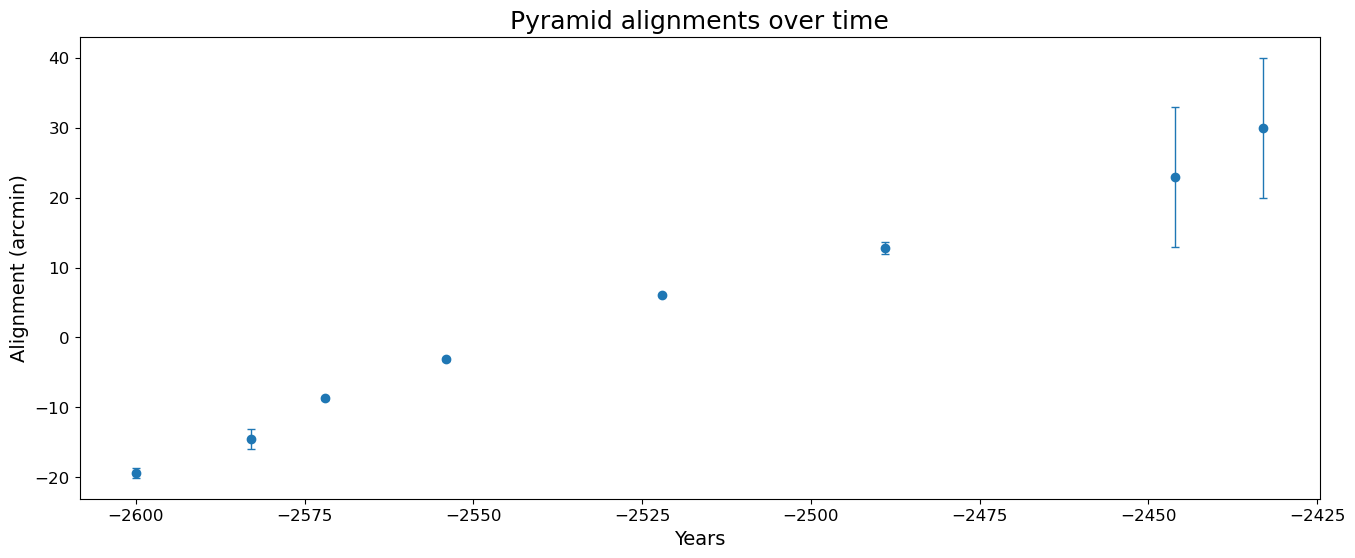

In [143]:
time = 0 - year
fig, ax = plt.subplots(figsize=(16, 6))
ax.errorbar(time, alignment, yerr=ealignment, fmt='o', ecolor='C0', elinewidth=1, capsize=3, capthick=1)
ax.set_xlabel("Years", fontsize=14)
ax.set_ylabel("Alignment (arcmin)", fontsize=14)
ax.set_title("Pyramid alignments over time", fontsize=18)
ax.tick_params(axis='both', labelsize=12);

In [144]:
def lin_func(x, a, b):
    return a*x + b

In [145]:
cfit = cost.LeastSquares(time, alignment, ealignment, lin_func)

mfit = Minuit(cfit, a=0.24, b=600)
mfit.migrad();

In [146]:
# First, check if the result was a valid minimum:
if (not mfit.fmin.is_valid) :
    print("  WARNING: The ChiSquare fit DID NOT converge!!! ")    

# Loop to get both parameter values and uncertainties:
for name in mfit.parameters :
    value, error = mfit.values[name], mfit.errors[name]
    print(f"Fit value: {name} = {value:.5f} +/- {error:.5f}")

# Get Chi2 value:
chi2_value = mfit.fval            # The value minimised, i.e. Chi2 or -2*LogLikeliHood (LLH) value

# Get number of degrees-of-freedom (Ndof):
N_NotEmptyBin = len(alignment)
Ndof_value = N_NotEmptyBin - mfit.nfit

Prob_value = stats.chi2.sf(chi2_value, Ndof_value) # The chi2 probability given N_DOF degrees of freedom
print(f"Chi2 value: {chi2_value:.1f}   Ndof = {Ndof_value:.0f}    Prob(Chi2,Ndof) = {Prob_value:5.3f}")

Fit value: a = 0.29471 +/- 0.00418
Fit value: b = 749.25006 +/- 10.63716
Chi2 value: 28.4   Ndof = 6    Prob(Chi2,Ndof) = 0.000


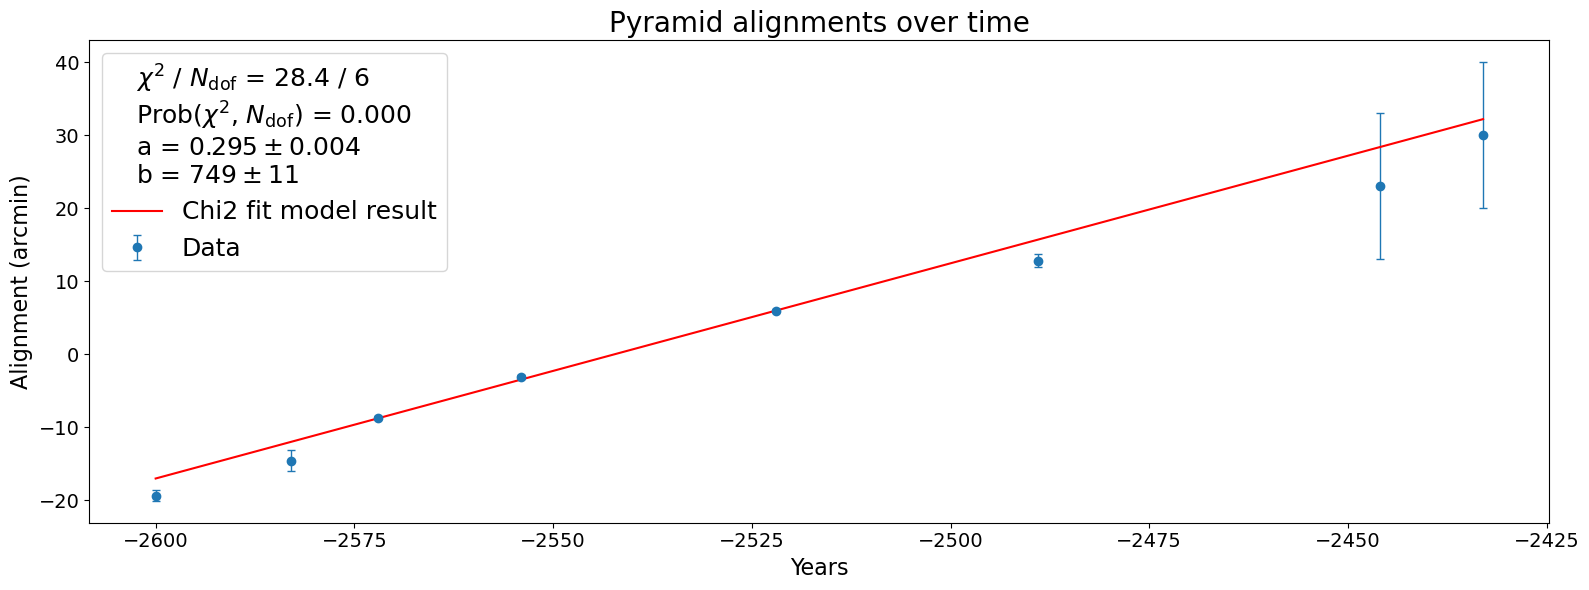

In [147]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.errorbar(time, alignment, yerr=ealignment, fmt='o', ecolor='C0', elinewidth=1, capsize=3, capthick=1, label = 'Data')
ax.set_xlabel("Years", fontsize=16)
ax.set_ylabel("Alignment (arcmin)", fontsize=16)
ax.set_title("Pyramid alignments over time", fontsize=20)
ax.tick_params(axis='both', labelsize=14);

# Adding fit function to plot:
x_axis = np.linspace(time.min(), time.max(), 1000)
ax.plot(x_axis, lin_func(x_axis, *mfit.values[:]), '-r', label= r"Chi2 fit model result") 

# Adding fit results to plot:
chi2 = mfit.fval                     # ChiSquare value
Ndof = len(alignment) - mfit.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit.parameters, mfit.values[:], mfit.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=18, title_fontsize = 18, alignment = 'center');
fig.tight_layout()

In [148]:
z_slope = (mfit.values['a'] - 0.274)/mfit.errors['a']
p_slope = stats.norm.sf(np.abs(z_slope))*2
print(f"Slope significance: Z = {z_slope:.2f}, p-value = {p_slope:.4f}")

Slope significance: Z = 4.95, p-value = 0.0000


In [149]:
time_khufu = 2467 - alignment[3]/mfit.values['a']
eitme_khufu =np.sqrt((ealignment[3]/mfit.values['a'])**2 + (alignment[3]*mfit.errors['a']/(mfit.values['a']**2))**2)
print(f"Time of Khufu alignment: {time_khufu:.1f} +/- {eitme_khufu:.1f} BC")

Time of Khufu alignment: 2477.5 +/- 0.7 BC
